# 🧪 Molecular Machine Learning & ChemBERT

## Molecular Property Prediction with DeepChem, MoleculeNet, and Transformers

This project explores machine learning approaches for molecular representation and property prediction, combining classical molecular featurization with deep learning and pretrained chemical language models.

Using **DeepChem**, **MoleculeNet**, **RDKit**, and **ChemBERT**, the workflow investigates how different molecular representations influence predictive performance and how pretrained Transformer models can be adapted to downstream molecular classification tasks.

The project covers the complete workflow from molecular data exploration and representation to model training, evaluation, and transfer learning under limited-data conditions.

## 🎯 Project Scope

- Explore molecular datasets from **MoleculeNet** using DeepChem.
- Compare alternative molecular representations and featurization strategies.
- Build feedforward neural networks for molecular property prediction.
- Use **RDKit** for molecular structure visualization and conformer analysis.
- Apply pretrained **ChemBERT** to masked SMILES token prediction.
- Fine-tune ChemBERT for downstream molecular classification.
- Compare conventional molecular representations with learned sequence representations.
- Evaluate the effect of training-set size on transfer-learning performance.

## 🔬 Key Technologies

**Python · PyTorch · DeepChem · RDKit · Hugging Face Transformers · ChemBERT · MoleculeNet · Scikit-learn**

In [1]:
from pathlib import Path
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger("deepchem").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import deepchem as dc

from rdkit import Chem, RDLogger
from rdkit.Chem import Draw, AllChem

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    mean_squared_error,
    classification_report,
)

from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    AutoModelForSequenceClassification,
)

RDLogger.DisableLog("rdApp.*")


# Reproducibility
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


# Runtime configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Project directories
RESULTS_DIR = Path("../results")
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
MODELS_DIR = RESULTS_DIR / "models"

for directory in (FIGURES_DIR, TABLES_DIR, MODELS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

In [2]:
print("Environment check")
print("-" * 40)
print(f"DeepChem version : {dc.__version__}")
print(f"PyTorch version  : {torch.__version__}")
print(f"Compute device   : {DEVICE}")
print(f"RDKit available  : {Chem.MolFromSmiles('C=CCO') is not None}")

Environment check
----------------------------------------
DeepChem version : 2.8.0
PyTorch version  : 2.12.1
Compute device   : cpu
RDKit available  : True


# 1. Molecular Data Exploration with DeepChem and MoleculeNet

This section examines the structure of molecular datasets available through **DeepChem** and **MoleculeNet**, with particular attention to how molecular inputs, prediction targets, sample weights, and dataset splits are represented.

Different molecular featurization strategies are also explored to understand how chemical structures can be transformed into numerical representations suitable for machine learning.

This initial analysis provides the foundation for the predictive models developed in subsequent sections.

In [3]:
available_datasets = sorted(
    method.removeprefix("load_")
    for method in dir(dc.molnet)
    if method.startswith("load_")
)

print(f"Available MoleculeNet datasets: {len(available_datasets)}")
print(available_datasets[:30])

Available MoleculeNet datasets: 45
['Platinum_Adsorption', 'bace_classification', 'bace_regression', 'bandgap', 'bbbc001', 'bbbc002', 'bbbc003', 'bbbc004', 'bbbc005', 'bbbp', 'cell_counting', 'chembl', 'chembl25', 'clearance', 'clintox', 'delaney', 'factors', 'freesolv', 'function', 'hiv', 'hopv', 'hppb', 'kaggle', 'kinase', 'lipo', 'mp_formation_energy', 'mp_metallicity', 'muv', 'nci', 'pcba']


## 1.1 ClinTox Dataset

The **ClinTox** dataset is used as the main classification benchmark in this project.

ClinTox contains molecular structures represented as SMILES together with binary labels related to clinical toxicity outcomes. DeepChem provides predefined training, validation, and test splits, as well as multiple molecular featurization strategies that can be used to compare different input representations.

The first experiments use **ECFP molecular fingerprints** as a fixed-length representation for downstream neural-network classification.

In [4]:
tasks, clintox_splits, transformers = dc.molnet.load_clintox(
    featurizer="ECFP"
)

train, valid, test = clintox_splits

print("ClinTox loaded successfully")
print(f"Tasks: {tasks}")
print(f"Train samples      : {len(train)}")
print(f"Validation samples : {len(valid)}")
print(f"Test samples       : {len(test)}")

ClinTox loaded successfully
Tasks: ['FDA_APPROVED', 'CT_TOX']
Train samples      : 1184
Validation samples : 148
Test samples       : 148


In [5]:
dataset_summary = pd.DataFrame(
    {
        "Split": ["Train", "Validation", "Test"],
        "Samples": [len(train), len(valid), len(test)],
        "X shape": [train.X.shape, valid.X.shape, test.X.shape],
        "y shape": [train.y.shape, valid.y.shape, test.y.shape],
        "w shape": [train.w.shape, valid.w.shape, test.w.shape],
    }
)

dataset_summary

,Split,Samples,X shape,y shape,w shape
0,Train,1184,"(1184, 1024)","(1184, 2)","(1184, 2)"
1,Validation,148,"(148, 1024)","(148, 2)","(148, 2)"
2,Test,148,"(148, 1024)","(148, 2)","(148, 2)"


In [6]:
print("Example molecule")
print("-" * 40)
print(f"SMILES  : {train.ids[0]}")
print(f"Targets : {train.y[0]}")
print(f"Weights : {train.w[0]}")

Example molecule
----------------------------------------
SMILES  : B([C@H](CC(C)C)NC(=O)CNC(=O)C1=C(C=CC(=C1)Cl)Cl)(O)O
Targets : [0. 1.]
Weights : [14.98734177 12.46315789]


### Dataset Structure and Molecular Representation

DeepChem organizes the ClinTox benchmark into three predefined splits: **training, validation, and test**. Each sample contains four main components:

- **`X`** — molecular features used as model inputs.
- **`y`** — prediction targets for each molecular task.
- **`w`** — task-specific sample weights used to account for missing labels and dataset structure.
- **`ids`** — molecular identifiers, represented here as SMILES strings.

Using the **ECFP featurizer**, each molecule is encoded as a fixed-length **1024-dimensional molecular fingerprint**.

ClinTox contains two binary prediction tasks:

- `FDA_APPROVED`
- `CT_TOX`

The following summary verifies that the same molecular representation and target structure are maintained across all dataset splits.

In [7]:
summary = pd.DataFrame(
    {
        "Split": ["Train", "Validation", "Test"],
        "Samples": [
            train.X.shape[0],
            valid.X.shape[0],
            test.X.shape[0],
        ],
        "Feature dimensions": [
            train.X.shape[1],
            valid.X.shape[1],
            test.X.shape[1],
        ],
        "Prediction tasks": [
            train.y.shape[1],
            valid.y.shape[1],
            test.y.shape[1],
        ],
    }
)
summary.to_csv(
    TABLES_DIR / "dataset_summary_clintox_ecfp.csv",
    index=False,
)
summary

,Split,Samples,Feature dimensions,Prediction tasks
0,Train,1184,1024,2
1,Validation,148,1024,2
2,Test,148,1024,2


Example SMILES: B([C@H](CC(C)C)NC(=O)CNC(=O)C1=C(C=CC(=C1)Cl)Cl)(O)O


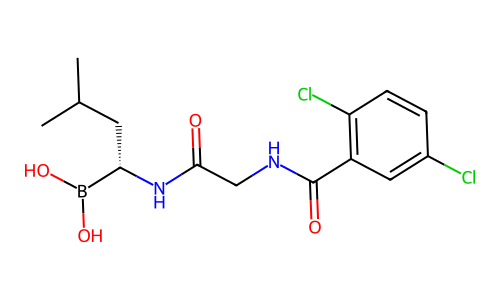

In [8]:
example_smiles = train.ids[0]
example_molecule = Chem.MolFromSmiles(example_smiles)

print(f"Example SMILES: {example_smiles}")

Draw.MolToImage(
    example_molecule,
    size=(500, 300),
)

### Molecular Structure Visualization

Because the dataset identifiers are stored as **SMILES strings**, they can be converted back into molecular graphs with RDKit.

The example below illustrates the connection between the textual molecular representation used by the dataset and its corresponding chemical structure.

### Interpretation

The initial exploration of ClinTox highlights several properties that are important for the modeling workflow.

#### Fixed-length molecular representation

With the **ECFP featurizer**, every molecule is represented by a **1024-dimensional fingerprint**, regardless of the size or complexity of the original molecular structure.

This fixed-length representation makes the molecular data directly compatible with conventional machine-learning and feedforward neural-network architectures.

#### Multi-task target structure

ClinTox provides two binary classification tasks:

- **`FDA_APPROVED`**
- **`CT_TOX`**

Accordingly, the target matrix `y` contains one column per prediction task. The weight matrix `w` follows the same task-wise structure and provides sample weights for the corresponding labels.

This organization allows DeepChem datasets to support multi-task molecular prediction within a common data structure.

#### SMILES as molecular identifiers

Dataset identifiers are stored as **SMILES strings**, preserving a textual representation of each molecular structure alongside its numerical features.

For example:

`B(C@HNC(=O)CNC(=O)C1=C(C=CC(=C1)Cl)Cl)(O)O`

Using RDKit, these SMILES strings can be converted into molecular graphs for visualization and structural analysis.

This distinction between **raw molecular representations (SMILES)** and **derived numerical features (ECFP fingerprints)** becomes important in the following experiments, where alternative molecular representations are compared for predictive modeling.


## 2. Comparing Molecular Featurization Strategies

Molecular machine-learning models depend strongly on how chemical structures are represented numerically.

The previous section used **ECFP fingerprints**, which encode molecules as fixed-length vectors. Here, several alternative DeepChem representations are compared to examine how the same molecular dataset can be expressed as fingerprints, molecular graphs, or raw SMILES.

The representations evaluated are:

- **ECFP** — fixed-length circular molecular fingerprints.
- **GraphConv** — molecular graph representations designed for graph-based neural networks.
- **Weave** — atom- and pair-level graph features for molecular modeling.
- **Raw** — unprocessed molecular representations, preserving the original SMILES-based input.

This comparison illustrates how the choice of featurization determines both the structure of the model input and the family of machine-learning architectures that can be applied downstream.

In [9]:
selected_featurizers = ["ECFP", "GraphConv", "Weave", "Raw"]

featurizer_results = []

for featurizer_name in selected_featurizers:
    try:
        _, splits, _ = dc.molnet.load_clintox(
            featurizer=featurizer_name
        )

        train_split, valid_split, test_split = splits
        example_features = train_split.X[0]

        featurizer_results.append(
            {
                "Featurizer": featurizer_name,
                "Train samples": len(train_split),
                "Input container shape": str(train_split.X.shape),
                "Example representation": type(example_features).__name__,
                "Example shape": str(
                    getattr(example_features, "shape", "variable / object")
                ),
            }
        )

    except Exception as error:
        featurizer_results.append(
            {
                "Featurizer": featurizer_name,
                "Train samples": np.nan,
                "Input container shape": "Not available",
                "Example representation": "Loading failed",
                "Example shape": type(error).__name__,
            }
        )

featurizer_comparison = pd.DataFrame(featurizer_results)

featurizer_comparison.to_csv(
    TABLES_DIR / "featurizer_comparison_clintox.csv",
    index=False,
)

featurizer_comparison

,Featurizer,Train samples,Input container shape,Example representation,Example shape
0,ECFP,1184,"(1184, 1024)",ndarray,"(1024,)"
1,GraphConv,1184,"(1184,)",ConvMol,variable / object
2,Weave,1184,"(1184,)",WeaveMol,variable / object
3,Raw,1184,"(1184,)",Mol,variable / object


### Representation Analysis

The featurization comparison shows that molecular representations differ substantially in both **data structure** and **model compatibility**.

**ECFP** produces a fixed-length numerical representation, with each molecule encoded as a 1024-dimensional fingerprint. This representation can be used directly as input to conventional machine-learning algorithms or feedforward neural networks.

In contrast, **GraphConv** and **Weave** preserve molecular topology through structured graph-based objects rather than fixed-length feature vectors. Their representations encode atom-level and connectivity information and therefore require architectures specifically designed to operate on molecular graphs.

The **Raw** representation preserves the molecular structure without converting it into a fixed-length feature matrix, making additional preprocessing or representation learning necessary before it can be used by most predictive models.

These differences highlight an important modeling decision: **molecular featurization and model architecture cannot be selected independently**. The representation determines which structural information is exposed to the model and which classes of predictive architectures can process it effectively.

For the first predictive baseline, **ECFP fingerprints** provide a suitable representation because they combine fixed dimensionality with direct compatibility with a feedforward neural network. Later sections move toward learned representations derived directly from SMILES and pretrained molecular language models.

## 3. ECFP Baseline for Molecular Toxicity Prediction

A feedforward neural network is used as the first predictive baseline for molecular classification.

The model receives the **1024-dimensional ECFP fingerprints** generated in the previous section and predicts the `CT_TOX` endpoint from ClinTox.

Because molecular toxicity datasets can exhibit substantial class imbalance, model performance is evaluated using both threshold-dependent and ranking-based metrics. In particular, **ROC-AUC, balanced accuracy, precision, recall, and F1-score** are considered alongside conventional accuracy.

This baseline provides a reference point for evaluating whether learned SMILES representations and pretrained molecular language models offer advantages over fixed molecular fingerprints.

In [10]:
target_task = "CT_TOX"
target_idx = list(tasks).index(target_task)

print(f"Selected prediction task: {target_task}")
print(f"Task index: {target_idx}")

Selected prediction task: CT_TOX
Task index: 1


In [11]:
X_train = torch.tensor(train.X, dtype=torch.float32)
X_valid = torch.tensor(valid.X, dtype=torch.float32)
X_test = torch.tensor(test.X, dtype=torch.float32)

y_train = torch.tensor(train.y[:, target_idx], dtype=torch.long)
y_valid = torch.tensor(valid.y[:, target_idx], dtype=torch.long)
y_test = torch.tensor(test.y[:, target_idx], dtype=torch.long)

w_train = torch.tensor(train.w[:, target_idx], dtype=torch.float32)
w_valid = torch.tensor(valid.w[:, target_idx], dtype=torch.float32)
w_test = torch.tensor(test.w[:, target_idx], dtype=torch.float32)

print("Tensor shapes")
print("-" * 40)
print(f"Train      : X={tuple(X_train.shape)}, y={tuple(y_train.shape)}")
print(f"Validation : X={tuple(X_valid.shape)}, y={tuple(y_valid.shape)}")
print(f"Test       : X={tuple(X_test.shape)}, y={tuple(y_test.shape)}")

print("\nClass distribution")
print("-" * 40)
print(f"Train      : {torch.bincount(y_train).tolist()}")
print(f"Validation : {torch.bincount(y_valid).tolist()}")
print(f"Test       : {torch.bincount(y_test).tolist()}")

print("\nValid-label weights")
print("-" * 40)
print(f"Train      : {(w_train > 0).sum().item()} / {len(w_train)}")
print(f"Validation : {(w_valid > 0).sum().item()} / {len(w_valid)}")
print(f"Test       : {(w_test > 0).sum().item()} / {len(w_test)}")

Tensor shapes
----------------------------------------
Train      : X=(1184, 1024), y=(1184,)
Validation : X=(148, 1024), y=(148,)
Test       : X=(148, 1024), y=(148,)

Class distribution
----------------------------------------
Train      : [1089, 95]
Validation : [141, 7]
Test       : [138, 10]

Valid-label weights
----------------------------------------
Train      : 1184 / 1184
Validation : 148 / 148
Test       : 148 / 148


In [12]:
TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 64

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
)

valid_loader = DataLoader(
    TensorDataset(X_valid, y_valid),
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
)

In [13]:
class FeedForwardClassifier(nn.Module):
    """Feedforward neural network for ECFP-based molecular classification."""

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int = 128,
        num_classes: int = 2,
        dropout: float = 0.25,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x):
        return self.network(x)

In [14]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    mean_squared_error,
    classification_report,
)


def evaluate_classifier(model, loader, criterion):
    """Evaluate a binary classifier using imbalance-aware metrics."""

    model.eval()

    losses = []
    all_predictions = []
    all_probabilities = []
    all_labels = []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = model(features)
            loss = criterion(logits, labels)

            probabilities = torch.softmax(logits, dim=1)[:, 1]
            predictions = torch.argmax(logits, dim=1)

            losses.append(loss.item())
            all_probabilities.extend(probabilities.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    metrics = {
        "loss": np.mean(losses),
        "accuracy": accuracy_score(all_labels, all_predictions),
        "balanced_accuracy": balanced_accuracy_score(
            all_labels,
            all_predictions,
        ),
        "precision": precision_score(
            all_labels,
            all_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            all_labels,
            all_predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            all_labels,
            all_predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            all_labels,
            all_probabilities,
        ),
        "auprc": average_precision_score(
            all_labels,
            all_probabilities,
        ),
    }

    return metrics
print(evaluate_classifier.__name__)

evaluate_classifier


In [15]:
class_counts = torch.bincount(y_train)

negative_count = class_counts[0].item()
positive_count = class_counts[1].item()

positive_class_weight = negative_count / positive_count

class_weights = torch.tensor(
    [1.0, positive_class_weight],
    dtype=torch.float32,
    device=DEVICE,
)

print(f"Positive-class weight: {positive_class_weight:.3f}")

input_dim = X_train.shape[1]

ff_model = FeedForwardClassifier(
    input_dim=input_dim
).to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    ff_model.parameters(),
    lr=1e-3,
)

Positive-class weight: 11.463


In [16]:
import copy

N_EPOCHS = 30

history = []

best_validation_auprc = -np.inf
best_epoch = None
best_model_state = None

for epoch in range(1, N_EPOCHS + 1):
    ff_model.train()

    for features, labels in train_loader:
        features = features.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        logits = ff_model(features)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

    train_metrics = evaluate_classifier(
        ff_model,
        train_loader,
        criterion,
    )

    valid_metrics = evaluate_classifier(
        ff_model,
        valid_loader,
        criterion,
    )

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "validation_loss": valid_metrics["loss"],
            "train_auprc": train_metrics["auprc"],
            "validation_auprc": valid_metrics["auprc"],
            "train_roc_auc": train_metrics["roc_auc"],
            "validation_roc_auc": valid_metrics["roc_auc"],
            "train_balanced_accuracy": train_metrics[
                "balanced_accuracy"
            ],
            "validation_balanced_accuracy": valid_metrics[
                "balanced_accuracy"
            ],
        }
    )

    if valid_metrics["auprc"] > best_validation_auprc:
        best_validation_auprc = valid_metrics["auprc"]
        best_epoch = epoch
        best_model_state = copy.deepcopy(
            ff_model.state_dict()
        )

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d} | "
            f"Train loss={train_metrics['loss']:.4f} | "
            f"Val loss={valid_metrics['loss']:.4f} | "
            f"Train AUPRC={train_metrics['auprc']:.3f} | "
            f"Val AUPRC={valid_metrics['auprc']:.3f} | "
            f"Val ROC-AUC={valid_metrics['roc_auc']:.3f}"
        )

history_df = pd.DataFrame(history)

print(
    f"\nBest validation checkpoint: epoch {best_epoch} "
    f"(AUPRC={best_validation_auprc:.3f})"
)

Epoch 01 | Train loss=0.6388 | Val loss=0.6616 | Train AUPRC=0.536 | Val AUPRC=0.145 | Val ROC-AUC=0.579
Epoch 05 | Train loss=0.0992 | Val loss=2.2237 | Train AUPRC=0.908 | Val AUPRC=0.193 | Val ROC-AUC=0.635
Epoch 10 | Train loss=0.0719 | Val loss=3.0573 | Train AUPRC=0.943 | Val AUPRC=0.192 | Val ROC-AUC=0.628
Epoch 15 | Train loss=0.0501 | Val loss=4.2238 | Train AUPRC=0.966 | Val AUPRC=0.196 | Val ROC-AUC=0.622
Epoch 20 | Train loss=0.0483 | Val loss=4.5356 | Train AUPRC=0.966 | Val AUPRC=0.263 | Val ROC-AUC=0.632
Epoch 25 | Train loss=0.0460 | Val loss=5.1544 | Train AUPRC=0.968 | Val AUPRC=0.260 | Val ROC-AUC=0.625
Epoch 30 | Train loss=0.0424 | Val loss=5.7285 | Train AUPRC=0.972 | Val AUPRC=0.255 | Val ROC-AUC=0.626

Best validation checkpoint: epoch 3 (AUPRC=0.358)


In [17]:
ff_model.load_state_dict(best_model_state)

train_metrics = evaluate_classifier(
    ff_model,
    train_loader,
    criterion,
)

valid_metrics = evaluate_classifier(
    ff_model,
    valid_loader,
    criterion,
)

test_metrics = evaluate_classifier(
    ff_model,
    test_loader,
    criterion,
)

print(f"Best checkpoint restored from epoch {best_epoch}\n")

for split_name, metrics in {
    "Train": train_metrics,
    "Validation": valid_metrics,
    "Test": test_metrics,
}.items():
    print(split_name)
    print("-" * 40)
    print(f"Loss              : {metrics['loss']:.4f}")
    print(f"Accuracy          : {metrics['accuracy']:.3f}")
    print(f"Balanced accuracy : {metrics['balanced_accuracy']:.3f}")
    print(f"Precision         : {metrics['precision']:.3f}")
    print(f"Recall            : {metrics['recall']:.3f}")
    print(f"F1-score          : {metrics['f1']:.3f}")
    print(f"ROC-AUC           : {metrics['roc_auc']:.3f}")
    print(f"AUPRC             : {metrics['auprc']:.3f}")
    print()

Best checkpoint restored from epoch 3

Train
----------------------------------------
Loss              : 0.2117
Accuracy          : 0.906
Balanced accuracy : 0.944
Precision         : 0.461
Recall            : 0.989
F1-score          : 0.629
ROC-AUC           : 0.982
AUPRC             : 0.811

Validation
----------------------------------------
Loss              : 1.1933
Accuracy          : 0.932
Balanced accuracy : 0.761
Precision         : 0.364
Recall            : 0.571
F1-score          : 0.444
ROC-AUC           : 0.674
AUPRC             : 0.358

Test
----------------------------------------
Loss              : 0.6658
Accuracy          : 0.804
Balanced accuracy : 0.617
Precision         : 0.148
Recall            : 0.400
F1-score          : 0.216
ROC-AUC           : 0.679
AUPRC             : 0.406



In [18]:
ff_results = pd.DataFrame(
    [
        {
            "Model": "FeedForward + ECFP",
            "Task": target_task,
            "Best epoch": best_epoch,
            "Positive class weight": positive_class_weight,
            "Train accuracy": train_metrics["accuracy"],
            "Train balanced accuracy": train_metrics["balanced_accuracy"],
            "Train ROC-AUC": train_metrics["roc_auc"],
            "Train AUPRC": train_metrics["auprc"],
            "Validation accuracy": valid_metrics["accuracy"],
            "Validation balanced accuracy": valid_metrics["balanced_accuracy"],
            "Validation ROC-AUC": valid_metrics["roc_auc"],
            "Validation AUPRC": valid_metrics["auprc"],
            "Test accuracy": test_metrics["accuracy"],
            "Test balanced accuracy": test_metrics["balanced_accuracy"],
            "Test precision": test_metrics["precision"],
            "Test recall": test_metrics["recall"],
            "Test F1": test_metrics["f1"],
            "Test ROC-AUC": test_metrics["roc_auc"],
            "Test AUPRC": test_metrics["auprc"],
        }
    ]
)

ff_results.to_csv(
    TABLES_DIR / "feedforward_ecfp_results.csv",
    index=False,
)

history_df.to_csv(
    TABLES_DIR / "feedforward_ecfp_training_history.csv",
    index=False,
)

ff_results

,Model,Task,Best epoch,Positive class weight,Train accuracy,Train balanced accuracy,Train ROC-AUC,Train AUPRC,Validation accuracy,Validation balanced accuracy,Validation ROC-AUC,Validation AUPRC,Test accuracy,Test balanced accuracy,Test precision,Test recall,Test F1,Test ROC-AUC,Test AUPRC
0,FeedForward + ECFP,CT_TOX,3,11.463158,0.90625,0.944232,0.981523,0.810673,0.932432,0.760892,0.673759,0.358336,0.804054,0.616667,0.148148,0.4,0.216216,0.678986,0.406047


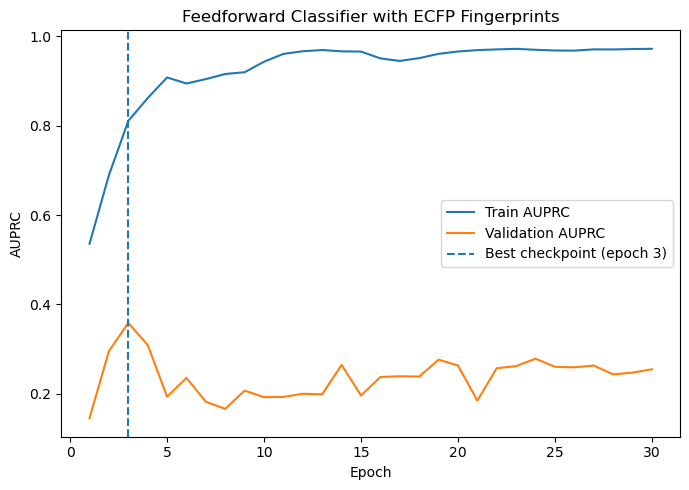

In [19]:
plt.figure(figsize=(7, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_auprc"],
    label="Train AUPRC",
)

plt.plot(
    history_df["epoch"],
    history_df["validation_auprc"],
    label="Validation AUPRC",
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best checkpoint (epoch {best_epoch})",
)

plt.xlabel("Epoch")
plt.ylabel("AUPRC")
plt.title("Feedforward Classifier with ECFP Fingerprints")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "feedforward_ecfp_auprc_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Baseline Performance and Model Selection

The ECFP-based feedforward classifier provides a useful baseline for the `CT_TOX` prediction task under substantial class imbalance. In the training split, only 95 of 1,184 molecules belong to the positive class, corresponding to an approximately **11.5:1 negative-to-positive ratio**.

To account for this imbalance, the training loss assigns a higher weight to the positive class based exclusively on the class distribution observed in the training set. Model selection is performed using **validation AUPRC**, rather than accuracy, because precision–recall metrics provide a more informative assessment when the positive class is rare.

The best validation performance was reached at **epoch 3**, with an AUPRC of **0.358**. Beyond this point, training AUPRC continued to increase while validation performance remained substantially lower, revealing a clear generalization gap and progressive overfitting.

After restoring the best validation checkpoint, the model achieved:

- **Test ROC-AUC:** 0.679
- **Test AUPRC:** 0.406
- **Test balanced accuracy:** 0.617
- **Test recall:** 0.400
- **Test precision:** 0.148
- **Test F1-score:** 0.216

Although conventional test accuracy reached 0.804, this value is strongly influenced by the majority negative class and therefore overstates practical classification performance. The imbalance-aware metrics provide a more realistic assessment of the model's ability to identify toxic compounds.

The relatively high training performance compared with validation and test performance indicates that the feedforward network can fit the ECFP representation effectively but generalizes only moderately to unseen molecules. This establishes a more rigorous baseline for evaluating whether learned molecular representations and pretrained chemical language models provide improved generalization in subsequent experiments.

## 4. Masked Molecular Language Modeling with ChemBERT

The previous experiments relied on fixed molecular fingerprints. This section introduces a pretrained molecular language model that operates directly on **SMILES sequences**.

**ChemBERT** was pretrained using a masked language modeling objective, learning contextual representations from large collections of molecular SMILES. Instead of relying on manually engineered molecular descriptors, the model processes tokenized chemical sequences and predicts masked tokens from their surrounding molecular context.

This section examines three components of the pretrained model:

- SMILES tokenization and sequence representation.
- Masked-token prediction from molecular context.
- Reconstruction and RDKit-based validation of candidate SMILES.

In [20]:
CHEMBERT_MODEL_NAME = "seyonec/PubChem10M_SMILES_BPE_450k"

tokenizer = AutoTokenizer.from_pretrained(
    CHEMBERT_MODEL_NAME
)

chembert_mlm = AutoModelForMaskedLM.from_pretrained(
    CHEMBERT_MODEL_NAME
).to(DEVICE)

chembert_mlm.eval()

print("ChemBERT configuration")
print("-" * 40)
print(f"Model              : {CHEMBERT_MODEL_NAME}")
print(f"Mask token         : {tokenizer.mask_token}")
print(f"Mask token ID      : {tokenizer.mask_token_id}")
print(f"Tokenizer vocab    : {tokenizer.vocab_size}")
print(f"Tokenizer length   : {len(tokenizer)}")
print(f"Model output vocab : {chembert_mlm.config.vocab_size}")

Some weights of the model checkpoint at seyonec/PubChem10M_SMILES_BPE_450k were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


ChemBERT configuration
----------------------------------------
Model              : seyonec/PubChem10M_SMILES_BPE_450k
Mask token         : <mask>
Mask token ID      : 4
Tokenizer vocab    : 7924
Tokenizer length   : 7924
Model output vocab : 52000


In [21]:
smiles_example = "CC1=CC=CC=C1C(=O)NC2=CC=CC=C2"

encoded_example = tokenizer(
    smiles_example,
    return_tensors="pt",
)

input_ids = encoded_example["input_ids"]

tokens = tokenizer.convert_ids_to_tokens(
    input_ids[0]
)

print("SMILES tokenization")
print("-" * 40)
print(f"SMILES          : {smiles_example}")
print(f"Input shape     : {tuple(input_ids.shape)}")
print(f"Sequence length : {input_ids.shape[1]}")
print("\nTokens:")
print(tokens)

SMILES tokenization
----------------------------------------
SMILES          : CC1=CC=CC=C1C(=O)NC2=CC=CC=C2
Input shape     : (1, 24)
Sequence length : 24

Tokens:
['<s>', 'CC', '1', '=', 'CC', '=', 'CC', '=', 'C', '1', 'C', '(=', 'O', ')', 'NC', '2', '=', 'CC', '=', 'CC', '=', 'C', '2', '</s>']


In [22]:
masked_smiles = "<mask>C1=CC=CC=C1C(=O)NC2=CC=CC=C2"

masked_encoding = tokenizer(
    masked_smiles,
    return_tensors="pt",
)

masked_encoding = {
    key: value.to(DEVICE)
    for key, value in masked_encoding.items()
}

with torch.no_grad():
    outputs = chembert_mlm(**masked_encoding)

logits = outputs.logits

print("Masked language model output")
print("-" * 40)
print(f"Input shape        : {tuple(masked_encoding['input_ids'].shape)}")
print(f"Logits shape       : {tuple(logits.shape)}")
print(f"Sequence length    : {logits.shape[1]}")
print(f"Output vocabulary  : {logits.shape[2]}")

Masked language model output
----------------------------------------
Input shape        : (1, 25)
Logits shape       : (1, 25, 52000)
Sequence length    : 25
Output vocabulary  : 52000


### Tokenization and Model Output

ChemBERT converts each SMILES string into a sequence of learned subword tokens together with the special tokens required by the pretrained model.

For masked language modeling, the `<mask>` token identifies the position whose molecular token must be reconstructed from the surrounding sequence context.

In the masked example above, the tokenized input has shape:

`(1, 25)`

where the first dimension corresponds to the batch size and the second to the tokenized sequence length.

The model returns a logits tensor with shape:

`(1, 25, 52000)`

following the general structure:

`(batch_size, sequence_length, model_output_vocabulary)`

This means that ChemBERT produces a score over the model's output vocabulary for every position in the molecular sequence.

An implementation detail worth noting is that the tokenizer reports a vocabulary size of **7,924 tokens**, whereas the masked-language-model head outputs logits over **52,000 positions**. For downstream analysis, the effective prediction space is therefore determined directly from the model output rather than inferred from the tokenizer metadata alone.

The mask token used by this model is `<mask>`, with token ID **4**.

### Masked SMILES Reconstruction

To examine ChemBERT's contextual molecular representations, selected SMILES sequences are modified by replacing one token with `<mask>`.

For each masked sequence, the model generates a ranked distribution of candidate tokens. The highest-scoring predictions are inserted back into the original SMILES to reconstruct candidate molecular strings.

The reconstructed SMILES are then parsed with **RDKit** to determine whether they correspond to syntactically valid molecular structures.

This provides a simple way to inspect how the pretrained language model uses local molecular context to propose plausible token replacements.

In [23]:
def predict_masked_smiles(masked_smiles, top_k=10):
    """
    Predict candidate tokens for a single masked position in a SMILES string
    and assess whether the reconstructed sequences can be parsed by RDKit.
    """

    encoding = tokenizer(
        masked_smiles,
        return_tensors="pt",
    )

    encoding = {
        key: value.to(DEVICE)
        for key, value in encoding.items()
    }

    input_ids = encoding["input_ids"]

    mask_positions = (
        input_ids == tokenizer.mask_token_id
    ).nonzero(as_tuple=False)

    if len(mask_positions) != 1:
        raise ValueError(
            "Each input SMILES must contain exactly one <mask> token."
        )

    mask_position = mask_positions[0, 1].item()

    with torch.no_grad():
        outputs = chembert_mlm(**encoding)

    mask_logits = outputs.logits[
        0,
        mask_position,
        :
    ]

    mask_probabilities = torch.softmax(
        mask_logits,
        dim=-1,
    )

    top_probabilities, top_token_ids = torch.topk(
        mask_probabilities,
        k=top_k,
    )

    predictions = []

    for rank, (token_id, probability) in enumerate(
        zip(top_token_ids, top_probabilities),
        start=1,
    ):
        token_id = token_id.item()
        probability = probability.item()

        predicted_token = tokenizer.decode(
            [token_id]
        ).strip()

        reconstructed_smiles = masked_smiles.replace(
            tokenizer.mask_token,
            predicted_token,
            1,
        )

        molecule = Chem.MolFromSmiles(
            reconstructed_smiles
        )

        predictions.append(
            {
                "rank": rank,
                "masked_smiles": masked_smiles,
                "predicted_token": predicted_token,
                "probability": probability,
                "reconstructed_smiles": reconstructed_smiles,
                "rdkit_parseable": molecule is not None,
            }
        )

    return pd.DataFrame(predictions)

In [24]:
masked_examples = {
    "Aromatic amide": "<mask>C1=CC=CC=C1C(=O)NC2=CC=CC=C2",
    "Phenol derivative": "CC1=CC=C(<mask>)C=C1O",
    "Chloro aromatic": "CCOC(=O)C1=CC=<mask>C=C1Cl",
}

prediction_tables = []

for example_name, masked_smiles in masked_examples.items():
    example_predictions = predict_masked_smiles(
        masked_smiles,
        top_k=10,
    )

    example_predictions.insert(
        0,
        "molecule_example",
        example_name,
    )

    prediction_tables.append(
        example_predictions
    )

chembert_predictions = pd.concat(
    prediction_tables,
    ignore_index=True,
)

chembert_predictions

,molecule_example,rank,masked_smiles,predicted_token,probability,reconstructed_smiles,rdkit_parseable
0,Aromatic amide,1,<mask>C1=CC=CC=C1C(=O)NC2=CC=CC=C2,[,0.865271,[C1=CC=CC=C1C(=O)NC2=CC=CC=C2,False
1,Aromatic amide,2,<mask>C1=CC=CC=C1C(=O)NC2=CC=CC=C2,1,0.071379,1C1=CC=CC=C1C(=O)NC2=CC=CC=C2,False
2,Aromatic amide,3,<mask>C1=CC=CC=C1C(=O)NC2=CC=CC=C2,CS,0.011761,CSC1=CC=CC=C1C(=O)NC2=CC=CC=C2,True
3,Aromatic amide,4,<mask>C1=CC=CC=C1C(=O)NC2=CC=CC=C2,O,0.006135,OC1=CC=CC=C1C(=O)NC2=CC=CC=C2,True
4,Aromatic amide,5,<mask>C1=CC=CC=C1C(=O)NC2=CC=CC=C2,),0.005426,)C1=CC=CC=C1C(=O)NC2=CC=CC=C2,False
5,Aromatic amide,6,<mask>C1=CC=CC=C1C(=O)NC2=CC=CC=C2,=,0.003867,=C1=CC=CC=C1C(=O)NC2=CC=CC=C2,False
6,Aromatic amide,7,<mask>C1=CC=CC=C1C(=O)NC2=CC=CC=C2,)[,0.003826,)[C1=CC=CC=C1C(=O)NC2=CC=CC=C2,False
7,Aromatic amide,8,<mask>C1=CC=CC=C1C(=O)NC2=CC=CC=C2,CCS,0.001717,CCSC1=CC=CC=C1C(=O)NC2=CC=CC=C2,True
8,Aromatic amide,9,<mask>C1=CC=CC=C1C(=O)NC2=CC=CC=C2,S,0.001433,SC1=CC=CC=C1C(=O)NC2=CC=CC=C2,True
9,Aromatic amide,10,<mask>C1=CC=CC=C1C(=O)NC2=CC=CC=C2,=[,0.001086,=[C1=CC=CC=C1C(=O)NC2=CC=CC=C2,False


In [25]:
chembert_predictions.to_csv(
    TABLES_DIR / "chembert_mask_predictions.csv",
    index=False,
)

In [26]:
valid_predictions = chembert_predictions[
    chembert_predictions["rdkit_parseable"]
].copy()

valid_predictions.head(10)

,molecule_example,rank,masked_smiles,predicted_token,probability,reconstructed_smiles,rdkit_parseable
2,Aromatic amide,3,<mask>C1=CC=CC=C1C(=O)NC2=CC=CC=C2,CS,0.011761,CSC1=CC=CC=C1C(=O)NC2=CC=CC=C2,True
3,Aromatic amide,4,<mask>C1=CC=CC=C1C(=O)NC2=CC=CC=C2,O,0.006135,OC1=CC=CC=C1C(=O)NC2=CC=CC=C2,True
7,Aromatic amide,8,<mask>C1=CC=CC=C1C(=O)NC2=CC=CC=C2,CCS,0.001717,CCSC1=CC=CC=C1C(=O)NC2=CC=CC=C2,True
8,Aromatic amide,9,<mask>C1=CC=CC=C1C(=O)NC2=CC=CC=C2,S,0.001433,SC1=CC=CC=C1C(=O)NC2=CC=CC=C2,True
10,Phenol derivative,1,CC1=CC=C(<mask>)C=C1O,C,0.495341,CC1=CC=C(C)C=C1O,True
11,Phenol derivative,2,CC1=CC=C(<mask>)C=C1O,O,0.104910,CC1=CC=C(O)C=C1O,True
12,Phenol derivative,3,CC1=CC=C(<mask>)C=C1O,Br,0.068743,CC1=CC=C(Br)C=C1O,True
13,Phenol derivative,4,CC1=CC=C(<mask>)C=C1O,CO,0.066065,CC1=CC=C(CO)C=C1O,True
14,Phenol derivative,5,CC1=CC=C(<mask>)C=C1O,Cl,0.045492,CC1=CC=C(Cl)C=C1O,True
15,Phenol derivative,6,CC1=CC=C(<mask>)C=C1O,CCO,0.035534,CC1=CC=C(CCO)C=C1O,True


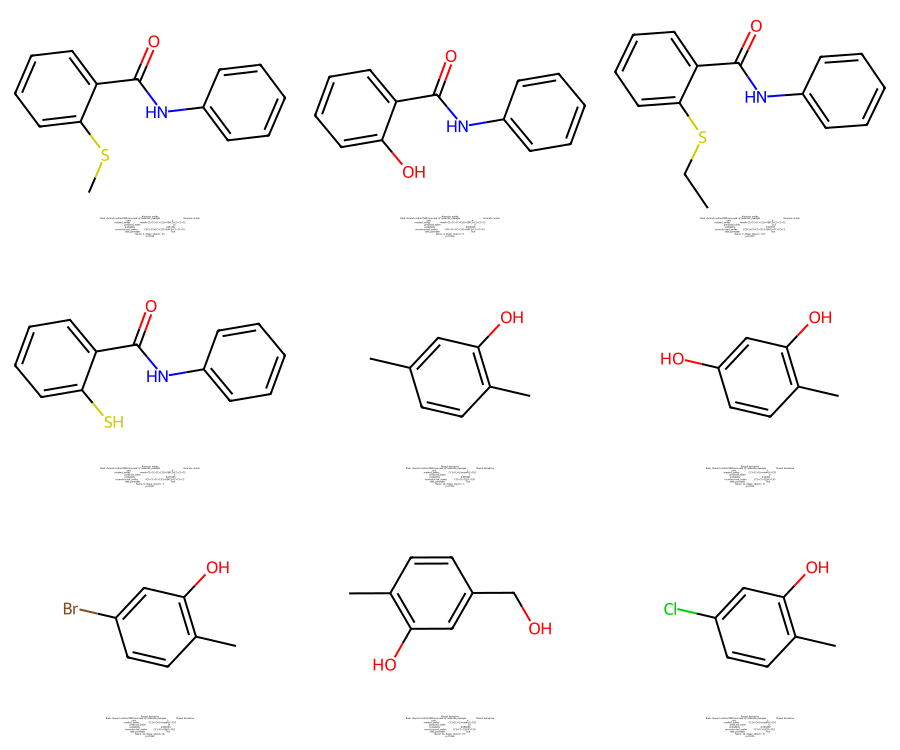

In [27]:
display_predictions = valid_predictions.head(9)

molecules = [
    Chem.MolFromSmiles(smiles)
    for smiles in display_predictions["reconstructed_smiles"]
]

legends = [
    (
        f"{row.molecule_example}\n"
        f"Rank {row.rank}: {row.predicted_token}\n"
        f"p={row.probability:.3f}"
    )
    for _, row in display_predictions.iterrows()
]

grid_image = Draw.MolsToGridImage(
    molecules,
    molsPerRow=3,
    subImgSize=(300, 250),
    legends=legends,
)

grid_image

### Interpretation of Masked Molecular Predictions

ChemBERT generates context-dependent token predictions for masked positions in SMILES sequences, providing a direct view of the molecular patterns captured during self-supervised pretraining.

The reconstruction experiments show that high-probability token predictions do not necessarily produce RDKit-parseable SMILES. For the **aromatic amide** example, the two highest-ranked predictions generated invalid SMILES syntax, while lower-ranked candidates such as `CS`, `O`, `CCS`, and `S` produced structures that could be successfully parsed.

In contrast, the **phenol derivative** example produced several parseable substitutions among its highest-ranked predictions, including `C`, `O`, `Br`, `CO`, and `Cl`. The highest-ranked candidate (`C`) received substantially greater probability than the remaining alternatives, illustrating how prediction confidence can vary depending on molecular context.

These results also highlight an important limitation of masked molecular language modeling: ChemBERT learns statistical patterns in SMILES sequences, but its prediction objective does not explicitly enforce molecular validity, synthetic accessibility, chemical stability, or biological relevance. RDKit parsing is therefore used here only as a lightweight syntactic and structural validation step, not as evidence that a predicted molecule is experimentally viable.

The experiment illustrates a fundamental difference between the molecular representations explored in this project. **ECFP fingerprints** encode predefined structural patterns into fixed-length feature vectors, whereas **ChemBERT learns contextual representations directly from molecular sequences through large-scale self-supervised pretraining**.

The next step evaluates whether this pretrained molecular representation can be transferred to a supervised downstream prediction task.

## 5. Learned SMILES Representations for Molecular Classification

To complement the fingerprint-based baseline, a second feedforward model is trained directly from **SMILES sequences**.

Instead of using predefined molecular descriptors, each SMILES string is converted into a sequence of character indices. The sequences are padded to a common length and passed through a trainable embedding layer that learns a task-specific molecular representation during supervised training.

This experiment provides an intermediate modeling strategy between:

- **ECFP fingerprints**, which rely on fixed engineered molecular features.
- **ChemBERT**, which uses representations learned during large-scale molecular pretraining.

The model is trained on the same `CT_TOX` classification task to enable comparison across molecular representation strategies.

In [47]:
tasks_raw, raw_splits, _ = dc.molnet.load_clintox(
    featurizer="Raw"
)

train_raw, valid_raw, test_raw = raw_splits

target_task = "CT_TOX"
target_idx = list(tasks_raw).index(target_task)

train_smiles = list(train_raw.ids)
valid_smiles = list(valid_raw.ids)
test_smiles = list(test_raw.ids)

y_train_smiles = torch.tensor(
    train_raw.y[:, target_idx],
    dtype=torch.long,
)

y_valid_smiles = torch.tensor(
    valid_raw.y[:, target_idx],
    dtype=torch.long,
)

y_test_smiles = torch.tensor(
    test_raw.y[:, target_idx],
    dtype=torch.long,
)

print("Raw SMILES dataset")
print("-" * 40)
print(f"Train samples      : {len(train_smiles)}")
print(f"Validation samples : {len(valid_smiles)}")
print(f"Test samples       : {len(test_smiles)}")
print(f"Target task        : {target_task}")
print(f"Example SMILES     : {train_smiles[0]}")

Raw SMILES dataset
----------------------------------------
Train samples      : 1184
Validation samples : 148
Test samples       : 148
Target task        : CT_TOX
Example SMILES     : B([C@H](CC(C)C)NC(=O)CNC(=O)C1=C(C=CC(=C1)Cl)Cl)(O)O


In [48]:
# Build the character vocabulary using training data only
all_chars = sorted(
    set("".join(train_smiles))
)

char_to_idx = {
    char: idx + 2
    for idx, char in enumerate(all_chars)
}

char_to_idx["<PAD>"] = 0
char_to_idx["<UNK>"] = 1

idx_to_char = {
    idx: char
    for char, idx in char_to_idx.items()
}

vocab_size = len(char_to_idx)

# Define sequence length using training data only
max_len = max(
    len(smiles)
    for smiles in train_smiles
)

print("SMILES vocabulary")
print("-" * 40)
print(f"Vocabulary size     : {vocab_size}")
print(f"Maximum train length: {max_len}")

print("\nSequence-length check")
print("-" * 40)
print(f"Max train length      : {max(len(s) for s in train_smiles)}")
print(f"Max validation length : {max(len(s) for s in valid_smiles)}")
print(f"Max test length       : {max(len(s) for s in test_smiles)}")

SMILES vocabulary
----------------------------------------
Vocabulary size     : 49
Maximum train length: 339

Sequence-length check
----------------------------------------
Max train length      : 339
Max validation length : 318
Max test length       : 263


In [49]:
def encode_smiles(
    smiles_list,
    char_to_idx,
    max_len,
):
    """Encode SMILES strings as padded character-index sequences."""

    pad_idx = char_to_idx["<PAD>"]
    unk_idx = char_to_idx["<UNK>"]

    encoded_sequences = []

    for smiles in smiles_list:
        encoded = [
            char_to_idx.get(char, unk_idx)
            for char in smiles
        ]

        # Truncate only if a sequence exceeds the training-defined max length
        encoded = encoded[:max_len]

        # Right-pad shorter sequences
        encoded += [pad_idx] * (max_len - len(encoded))

        encoded_sequences.append(encoded)

    return torch.tensor(
        encoded_sequences,
        dtype=torch.long,
    )

In [50]:
X_train_smiles = encode_smiles(
    train_smiles,
    char_to_idx,
    max_len,
)

X_valid_smiles = encode_smiles(
    valid_smiles,
    char_to_idx,
    max_len,
)

X_test_smiles = encode_smiles(
    test_smiles,
    char_to_idx,
    max_len,
)

print("Encoded SMILES tensors")
print("-" * 40)
print(f"Train      : {tuple(X_train_smiles.shape)}")
print(f"Validation : {tuple(X_valid_smiles.shape)}")
print(f"Test       : {tuple(X_test_smiles.shape)}")

Encoded SMILES tensors
----------------------------------------
Train      : (1184, 339)
Validation : (148, 339)
Test       : (148, 339)


In [51]:
TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 64

train_smiles_loader = DataLoader(
    TensorDataset(X_train_smiles, y_train_smiles),
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
)

valid_smiles_loader = DataLoader(
    TensorDataset(X_valid_smiles, y_valid_smiles),
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
)

test_smiles_loader = DataLoader(
    TensorDataset(X_test_smiles, y_test_smiles),
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
)

print("SMILES DataLoaders")
print("-" * 40)
print(f"Training batches   : {len(train_smiles_loader)}")
print(f"Validation batches : {len(valid_smiles_loader)}")
print(f"Test batches       : {len(test_smiles_loader)}")

SMILES DataLoaders
----------------------------------------
Training batches   : 37
Validation batches : 3
Test batches       : 3


In [52]:
class SmilesEmbeddingClassifier(nn.Module):
    """
    Character-level SMILES classifier with trainable embeddings
    and masked mean pooling over non-padding positions.
    """

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 32,
        hidden_dim: int = 128,
        dropout: float = 0.30,
        padding_idx: int = 0,
    ):
        super().__init__()

        self.padding_idx = padding_idx

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=padding_idx,
        )

        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 2),
        )

    def forward(self, x):
        embedded = self.embedding(x)

        mask = (
            x != self.padding_idx
        ).unsqueeze(-1)

        masked_embeddings = embedded * mask

        token_counts = mask.sum(dim=1).clamp(min=1)

        pooled = (
            masked_embeddings.sum(dim=1)
            / token_counts
        )

        return self.classifier(pooled)

In [53]:
smiles_model = SmilesEmbeddingClassifier(
    vocab_size=vocab_size,
    embedding_dim=32,
    hidden_dim=128,
    dropout=0.30,
    padding_idx=char_to_idx["<PAD>"],
).to(DEVICE)

class_counts_smiles = torch.bincount(y_train_smiles)

negative_count_smiles = class_counts_smiles[0].item()
positive_count_smiles = class_counts_smiles[1].item()

positive_class_weight_smiles = (
    negative_count_smiles / positive_count_smiles
)

class_weights_smiles = torch.tensor(
    [1.0, positive_class_weight_smiles],
    dtype=torch.float32,
    device=DEVICE,
)

criterion_smiles = nn.CrossEntropyLoss(
    weight=class_weights_smiles
)

optimizer_smiles = torch.optim.Adam(
    smiles_model.parameters(),
    lr=1e-3,
)

print(
    f"Positive-class weight: "
    f"{positive_class_weight_smiles:.3f}"
)

Positive-class weight: 11.463


In [54]:
import copy

N_EPOCHS_SMILES = 30

smiles_history = []

best_validation_auprc_smiles = -np.inf
best_epoch_smiles = None
best_model_state_smiles = None

for epoch in range(1, N_EPOCHS_SMILES + 1):
    smiles_model.train()

    for features, labels in train_smiles_loader:
        features = features.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer_smiles.zero_grad()

        logits = smiles_model(features)
        loss = criterion_smiles(logits, labels)

        loss.backward()
        optimizer_smiles.step()

    train_metrics_smiles = evaluate_classifier(
        smiles_model,
        train_smiles_loader,
        criterion_smiles,
    )

    valid_metrics_smiles = evaluate_classifier(
        smiles_model,
        valid_smiles_loader,
        criterion_smiles,
    )

    smiles_history.append(
        {
            "epoch": epoch,
            "train_loss": train_metrics_smiles["loss"],
            "validation_loss": valid_metrics_smiles["loss"],
            "train_auprc": train_metrics_smiles["auprc"],
            "validation_auprc": valid_metrics_smiles["auprc"],
            "train_roc_auc": train_metrics_smiles["roc_auc"],
            "validation_roc_auc": valid_metrics_smiles["roc_auc"],
            "train_balanced_accuracy": train_metrics_smiles[
                "balanced_accuracy"
            ],
            "validation_balanced_accuracy": valid_metrics_smiles[
                "balanced_accuracy"
            ],
        }
    )

    if valid_metrics_smiles["auprc"] > best_validation_auprc_smiles:
        best_validation_auprc_smiles = valid_metrics_smiles["auprc"]
        best_epoch_smiles = epoch
        best_model_state_smiles = copy.deepcopy(
            smiles_model.state_dict()
        )

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d} | "
            f"Train loss={train_metrics_smiles['loss']:.4f} | "
            f"Val loss={valid_metrics_smiles['loss']:.4f} | "
            f"Train AUPRC={train_metrics_smiles['auprc']:.3f} | "
            f"Val AUPRC={valid_metrics_smiles['auprc']:.3f} | "
            f"Val ROC-AUC={valid_metrics_smiles['roc_auc']:.3f}"
        )

smiles_history_df = pd.DataFrame(smiles_history)

print(
    f"\nBest validation checkpoint: epoch {best_epoch_smiles} "
    f"(AUPRC={best_validation_auprc_smiles:.3f})"
)

Epoch 01 | Train loss=0.4787 | Val loss=0.5252 | Train AUPRC=0.546 | Val AUPRC=0.824 | Val ROC-AUC=0.966
Epoch 05 | Train loss=0.1813 | Val loss=0.3213 | Train AUPRC=0.876 | Val AUPRC=0.892 | Val ROC-AUC=0.978
Epoch 10 | Train loss=0.1233 | Val loss=0.2986 | Train AUPRC=0.923 | Val AUPRC=0.901 | Val ROC-AUC=0.984
Epoch 15 | Train loss=0.1466 | Val loss=0.2988 | Train AUPRC=0.937 | Val AUPRC=0.901 | Val ROC-AUC=0.984
Epoch 20 | Train loss=0.0995 | Val loss=0.2957 | Train AUPRC=0.958 | Val AUPRC=0.907 | Val ROC-AUC=0.987
Epoch 25 | Train loss=0.0915 | Val loss=0.3084 | Train AUPRC=0.959 | Val AUPRC=0.905 | Val ROC-AUC=0.986
Epoch 30 | Train loss=0.0826 | Val loss=0.3565 | Train AUPRC=0.965 | Val AUPRC=0.903 | Val ROC-AUC=0.985

Best validation checkpoint: epoch 18 (AUPRC=0.907)


In [55]:
smiles_model.load_state_dict(best_model_state_smiles)

train_metrics_smiles = evaluate_classifier(
    smiles_model,
    train_smiles_loader,
    criterion_smiles,
)

valid_metrics_smiles = evaluate_classifier(
    smiles_model,
    valid_smiles_loader,
    criterion_smiles,
)

test_metrics_smiles = evaluate_classifier(
    smiles_model,
    test_smiles_loader,
    criterion_smiles,
)

print(
    f"Best checkpoint restored from epoch "
    f"{best_epoch_smiles}\n"
)

for split_name, metrics in {
    "Train": train_metrics_smiles,
    "Validation": valid_metrics_smiles,
    "Test": test_metrics_smiles,
}.items():
    print(split_name)
    print("-" * 40)
    print(f"Loss              : {metrics['loss']:.4f}")
    print(f"Accuracy          : {metrics['accuracy']:.3f}")
    print(f"Balanced accuracy : {metrics['balanced_accuracy']:.3f}")
    print(f"Precision         : {metrics['precision']:.3f}")
    print(f"Recall            : {metrics['recall']:.3f}")
    print(f"F1-score          : {metrics['f1']:.3f}")
    print(f"ROC-AUC           : {metrics['roc_auc']:.3f}")
    print(f"AUPRC             : {metrics['auprc']:.3f}")
    print()

Best checkpoint restored from epoch 18

Train
----------------------------------------
Loss              : 0.1004
Accuracy          : 0.958
Balanced accuracy : 0.948
Precision         : 0.669
Recall            : 0.937
F1-score          : 0.781
ROC-AUC           : 0.994
AUPRC             : 0.954

Validation
----------------------------------------
Loss              : 0.3190
Accuracy          : 0.959
Balanced accuracy : 0.911
Precision         : 0.545
Recall            : 0.857
F1-score          : 0.667
ROC-AUC           : 0.987
AUPRC             : 0.907

Test
----------------------------------------
Loss              : 0.2023
Accuracy          : 0.966
Balanced accuracy : 0.936
Precision         : 0.692
Recall            : 0.900
F1-score          : 0.783
ROC-AUC           : 0.988
AUPRC             : 0.896



In [56]:
smiles_results = pd.DataFrame(
    [
        {
            "Model": "Character-level SMILES Embedding",
            "Task": target_task,
            "Best epoch": best_epoch_smiles,
            "Positive class weight": positive_class_weight_smiles,
            "Train accuracy": train_metrics_smiles["accuracy"],
            "Train balanced accuracy": train_metrics_smiles[
                "balanced_accuracy"
            ],
            "Train ROC-AUC": train_metrics_smiles["roc_auc"],
            "Train AUPRC": train_metrics_smiles["auprc"],
            "Validation accuracy": valid_metrics_smiles["accuracy"],
            "Validation balanced accuracy": valid_metrics_smiles[
                "balanced_accuracy"
            ],
            "Validation ROC-AUC": valid_metrics_smiles["roc_auc"],
            "Validation AUPRC": valid_metrics_smiles["auprc"],
            "Test accuracy": test_metrics_smiles["accuracy"],
            "Test balanced accuracy": test_metrics_smiles[
                "balanced_accuracy"
            ],
            "Test precision": test_metrics_smiles["precision"],
            "Test recall": test_metrics_smiles["recall"],
            "Test F1": test_metrics_smiles["f1"],
            "Test ROC-AUC": test_metrics_smiles["roc_auc"],
            "Test AUPRC": test_metrics_smiles["auprc"],
        }
    ]
)

smiles_history_df.to_csv(
    TABLES_DIR / "feedforward_smiles_training_history.csv",
    index=False,
)

smiles_results.to_csv(
    TABLES_DIR / "feedforward_smiles_results.csv",
    index=False,
)

smiles_results

,Model,Task,Best epoch,Positive class weight,Train accuracy,Train balanced accuracy,Train ROC-AUC,Train AUPRC,Validation accuracy,Validation balanced accuracy,Validation ROC-AUC,Validation AUPRC,Test accuracy,Test balanced accuracy,Test precision,Test recall,Test F1,Test ROC-AUC,Test AUPRC
0,Character-level SMILES Embedding,CT_TOX,18,11.463158,0.95777,0.948219,0.993833,0.95379,0.959459,0.910841,0.986829,0.907143,0.966216,0.935507,0.692308,0.9,0.782609,0.987681,0.895581


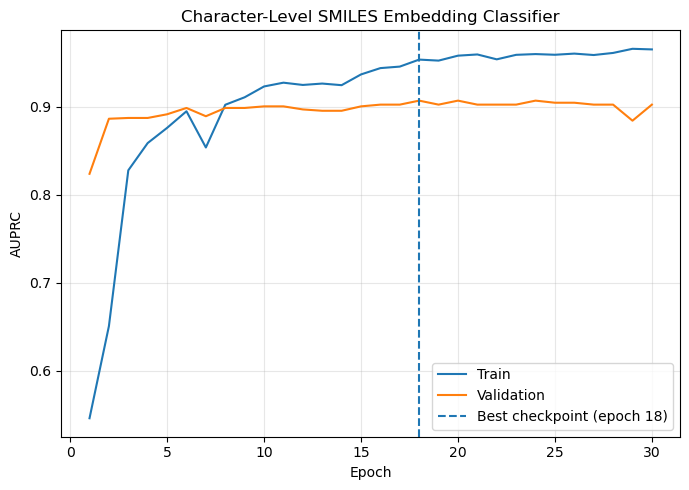

In [57]:
plt.figure(figsize=(7, 5))

plt.plot(
    smiles_history_df["epoch"],
    smiles_history_df["train_auprc"],
    label="Train",
)

plt.plot(
    smiles_history_df["epoch"],
    smiles_history_df["validation_auprc"],
    label="Validation",
)

plt.axvline(
    best_epoch_smiles,
    linestyle="--",
    label=f"Best checkpoint (epoch {best_epoch_smiles})",
)

plt.xlabel("Epoch")
plt.ylabel("AUPRC")
plt.title("Character-Level SMILES Embedding Classifier")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "smiles_embedding_auprc_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Representation and Data-Quality Audit

The character-level SMILES classifier achieved substantially higher validation and test performance than the ECFP baseline. Given the magnitude of this difference, the result warrants additional investigation before attributing the improvement to superior molecular representation learning.

SMILES are textual encodings of molecular structures and may contain representation-specific patterns that correlate with dataset composition or class labels. In addition, duplicated molecules, inconsistent labels, or overlap between dataset splits can produce artificially optimistic estimates of generalization performance.

To evaluate these possibilities, the following audit examines:

- molecular overlap across training, validation, and test splits after SMILES canonicalization;
- duplicated molecules and potentially conflicting labels;
- simple sequence-level characteristics associated with each class;
- the effect of canonicalizing SMILES before model training.

The goal is to distinguish genuine structure-related predictive signal from potential shortcuts associated with molecular serialization or dataset construction.

In [58]:
def canonicalize_smiles(smiles):
    """Convert a SMILES string to its canonical RDKit representation."""

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return Chem.MolToSmiles(
        mol,
        canonical=True,
        isomericSmiles=True,
    )


train_canonical = [
    canonicalize_smiles(smiles)
    for smiles in train_smiles
]

valid_canonical = [
    canonicalize_smiles(smiles)
    for smiles in valid_smiles
]

test_canonical = [
    canonicalize_smiles(smiles)
    for smiles in test_smiles
]


# Verify that all SMILES were successfully parsed
assert all(smiles is not None for smiles in train_canonical)
assert all(smiles is not None for smiles in valid_canonical)
assert all(smiles is not None for smiles in test_canonical)


train_canonical_set = set(train_canonical)
valid_canonical_set = set(valid_canonical)
test_canonical_set = set(test_canonical)


train_valid_overlap = (
    train_canonical_set & valid_canonical_set
)

train_test_overlap = (
    train_canonical_set & test_canonical_set
)

valid_test_overlap = (
    valid_canonical_set & test_canonical_set
)


print("Canonical SMILES split audit")
print("-" * 40)

print(
    f"Unique molecules — Train      : "
    f"{len(train_canonical_set)} / {len(train_canonical)}"
)

print(
    f"Unique molecules — Validation : "
    f"{len(valid_canonical_set)} / {len(valid_canonical)}"
)

print(
    f"Unique molecules — Test       : "
    f"{len(test_canonical_set)} / {len(test_canonical)}"
)

print("\nCross-split overlap")
print("-" * 40)

print(
    f"Train ∩ Validation : "
    f"{len(train_valid_overlap)}"
)

print(
    f"Train ∩ Test       : "
    f"{len(train_test_overlap)}"
)

print(
    f"Validation ∩ Test  : "
    f"{len(valid_test_overlap)}"
)

Canonical SMILES split audit
----------------------------------------
Unique molecules — Train      : 1165 / 1184
Unique molecules — Validation : 148 / 148
Unique molecules — Test       : 148 / 148

Cross-split overlap
----------------------------------------
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0


In [59]:
train_duplicate_audit = pd.DataFrame(
    {
        "raw_smiles": train_smiles,
        "canonical_smiles": train_canonical,
        "label": y_train_smiles.numpy(),
    }
)

duplicate_counts = (
    train_duplicate_audit
    .groupby("canonical_smiles")
    .size()
)

repeated_canonical = duplicate_counts[
    duplicate_counts > 1
].index

repeated_entries = train_duplicate_audit[
    train_duplicate_audit["canonical_smiles"].isin(
        repeated_canonical
    )
].copy()

duplicate_label_summary = (
    repeated_entries
    .groupby("canonical_smiles")
    .agg(
        samples=("label", "size"),
        unique_labels=("label", "nunique"),
        labels=("label", lambda x: sorted(x.tolist())),
    )
    .reset_index()
)

conflicting_duplicates = duplicate_label_summary[
    duplicate_label_summary["unique_labels"] > 1
].copy()

print("Training duplicate audit")
print("-" * 40)

print(
    "Canonical molecules with repeated entries : "
    f"{len(duplicate_label_summary)}"
)

print(
    "Repeated groups with conflicting labels   : "
    f"{len(conflicting_duplicates)}"
)

print(
    "Samples belonging to repeated groups      : "
    f"{len(repeated_entries)}"
)

Training duplicate audit
----------------------------------------
Canonical molecules with repeated entries : 19
Repeated groups with conflicting labels   : 19
Samples belonging to repeated groups      : 38


In [60]:
conflicting_duplicate_examples = (
    repeated_entries[
        repeated_entries["canonical_smiles"].isin(
            conflicting_duplicates["canonical_smiles"]
        )
    ]
    .sort_values(
        ["canonical_smiles", "label"]
    )
    .reset_index(drop=True)
)

print("Conflicting duplicate examples")
print("-" * 40)
print(
    f"Conflicting canonical molecules : "
    f"{conflicting_duplicates.shape[0]}"
)
print(
    f"Associated training samples     : "
    f"{conflicting_duplicate_examples.shape[0]}"
)

conflicting_duplicate_examples.head(10)

Conflicting duplicate examples
----------------------------------------
Conflicting canonical molecules : 19
Associated training samples     : 38


,raw_smiles,canonical_smiles,label
0,COCCOc1cc2c(cc1OCCOC)ncnc2Nc3cccc(c3)C#C,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1,0
1,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1,1
2,CC(=O)N1CCN(CC1)c2ccc(cc2)OC[C@H]3CO[C@](O3)(C...,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...,0
3,CC(=O)N1CCN(CC1)C2=CC=C(C=C2)OC[C@H]3CO[C@](O3...,CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4c...,1
4,CC(=O)O[C@H]1CC[C@@]2([C@H]3CC[C@]4([C@H]([C@@...,CC(=O)O[C@H]1CC[C@@]2(C)C(=CC[C@@H]3[C@@H]2CC[...,0
5,CC(=O)O[C@H]1CC[C@@]2([C@H]3CC[C@]4([C@H]([C@@...,CC(=O)O[C@H]1CC[C@@]2(C)C(=CC[C@@H]3[C@@H]2CC[...,1
6,CC(C)(C#N)c1cc(cc(c1)C(C)(C)C#N)Cn2cncn2,CC(C)(C#N)c1cc(Cn2cncn2)cc(C(C)(C)C#N)c1,0
7,CC(C)(C#N)C1=CC(=CC(=C1)CN2C=NC=N2)C(C)(C)C#N,CC(C)(C#N)c1cc(Cn2cncn2)cc(C(C)(C)C#N)c1,1
8,B([C@H](CC(C)C)NC(=O)[C@H](Cc1ccccc1)NC(=O)c2c...,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)c1cncc...,0
9,B([C@H](CC(C)C)NC(=O)[C@H](CC1=CC=CC=C1)NC(=O)...,CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)c1cncc...,1


In [61]:
def extract_smiles_string_features(smiles):
    """Extract simple representation-level features from a SMILES string."""

    return {
        "length": len(smiles),
        "uppercase": sum(char.isupper() for char in smiles),
        "lowercase": sum(char.islower() for char in smiles),
        "digits": sum(char.isdigit() for char in smiles),
        "branches": smiles.count("(") + smiles.count(")"),
        "double_bonds": smiles.count("="),
        "triple_bonds": smiles.count("#"),
        "bracket_atoms": smiles.count("["),
        "stereo_symbols": smiles.count("@"),
    }


def build_smiles_feature_table(
    smiles_list,
    labels,
    split_name,
):
    feature_rows = [
        extract_smiles_string_features(smiles)
        for smiles in smiles_list
    ]

    feature_df = pd.DataFrame(feature_rows)

    feature_df["label"] = np.asarray(labels)
    feature_df["split"] = split_name

    return feature_df


train_string_features = build_smiles_feature_table(
    train_smiles,
    y_train_smiles.numpy(),
    "Train",
)

valid_string_features = build_smiles_feature_table(
    valid_smiles,
    y_valid_smiles.numpy(),
    "Validation",
)

test_string_features = build_smiles_feature_table(
    test_smiles,
    y_test_smiles.numpy(),
    "Test",
)

smiles_string_features = pd.concat(
    [
        train_string_features,
        valid_string_features,
        test_string_features,
    ],
    ignore_index=True,
)

feature_columns = [
    "length",
    "uppercase",
    "lowercase",
    "digits",
    "branches",
    "double_bonds",
    "triple_bonds",
    "bracket_atoms",
    "stereo_symbols",
]

smiles_feature_summary = (
    smiles_string_features
    .groupby(["split", "label"])
    .agg(
        samples=("label", "size"),
        **{
            f"mean_{feature}": (feature, "mean")
            for feature in feature_columns
        },
    )
    .round(2)
)

smiles_feature_summary

samples  mean_length  mean_uppercase  mean_lowercase  \
split      label                                                         
Test       0          138        50.30           14.82           10.91   
           1           10        52.60           25.10            0.80   
Train      0         1089        57.23           20.36            7.34   
           1           95        69.46           32.11            0.31   
Validation 0          141        76.89           26.91            9.94   
           1            7        98.00           44.43            0.00   

                  mean_digits  mean_branches  mean_double_bonds  \
split      label                                                  
Test       0             6.50           9.71               1.90   
           1             6.20          10.80               8.00   
Train      0             5.21          11.28               2.30   
           1             6.94          13.47               7.71   
Validation 0             7.89          13.30               2.55   
           1             9.43          17.43               9.14   

                  mean_triple_bonds  mean_bracket_atoms  mean_stereo_symbols  
split      label                                                              
Test       0                   0.04                1.91                 1.28  
           1                   0.20                0.30                 0.40  
Train      0                   0.04                3.13                 3.03  
           1                   0.05                2.40                 3.40  
Validation 0                   0.05                4.72                 5.15  
           1                   0.14                5.00                 7.43

In [62]:
def canonicalize_smiles_or_raise(smiles):
    """Return a canonical RDKit SMILES or raise an error if parsing fails."""

    molecule = Chem.MolFromSmiles(smiles)

    if molecule is None:
        raise ValueError(
            f"RDKit could not parse SMILES: {smiles}"
        )

    return Chem.MolToSmiles(
        molecule,
        canonical=True,
        isomericSmiles=True,
    )


train_smiles_canonical = [
    canonicalize_smiles_or_raise(smiles)
    for smiles in train_smiles
]

valid_smiles_canonical = [
    canonicalize_smiles_or_raise(smiles)
    for smiles in valid_smiles
]

test_smiles_canonical = [
    canonicalize_smiles_or_raise(smiles)
    for smiles in test_smiles
]


print("Canonicalization check")
print("-" * 40)
print(f"Train samples      : {len(train_smiles_canonical)}")
print(f"Validation samples : {len(valid_smiles_canonical)}")
print(f"Test samples       : {len(test_smiles_canonical)}")

print("\nExample")
print("-" * 40)
print(f"Original  : {train_smiles[0]}")
print(f"Canonical : {train_smiles_canonical[0]}")

Canonicalization check
----------------------------------------
Train samples      : 1184
Validation samples : 148
Test samples       : 148

Example
----------------------------------------
Original  : B([C@H](CC(C)C)NC(=O)CNC(=O)C1=C(C=CC(=C1)Cl)Cl)(O)O
Canonical : CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B(O)O


In [63]:
# Build the character vocabulary from canonical training SMILES only
canonical_chars = sorted(
    set("".join(train_smiles_canonical))
)

canonical_char_to_idx = {
    char: idx + 2
    for idx, char in enumerate(canonical_chars)
}

canonical_char_to_idx["<PAD>"] = 0
canonical_char_to_idx["<UNK>"] = 1

canonical_vocab_size = len(canonical_char_to_idx)

# Define sequence length using canonical training data only
canonical_max_len = max(
    len(smiles)
    for smiles in train_smiles_canonical
)

print("Canonical SMILES vocabulary")
print("-" * 40)
print(f"Vocabulary size     : {canonical_vocab_size}")
print(f"Maximum train length: {canonical_max_len}")

print("\nSequence-length check")
print("-" * 40)
print(
    f"Max train length      : "
    f"{max(len(s) for s in train_smiles_canonical)}"
)
print(
    f"Max validation length : "
    f"{max(len(s) for s in valid_smiles_canonical)}"
)
print(
    f"Max test length       : "
    f"{max(len(s) for s in test_smiles_canonical)}"
)

Canonical SMILES vocabulary
----------------------------------------
Vocabulary size     : 50
Maximum train length: 323

Sequence-length check
----------------------------------------
Max train length      : 323
Max validation length : 318
Max test length       : 263


In [64]:
X_train_canonical = encode_smiles(
    train_smiles_canonical,
    canonical_char_to_idx,
    canonical_max_len,
)

X_valid_canonical = encode_smiles(
    valid_smiles_canonical,
    canonical_char_to_idx,
    canonical_max_len,
)

X_test_canonical = encode_smiles(
    test_smiles_canonical,
    canonical_char_to_idx,
    canonical_max_len,
)


train_canonical_loader = DataLoader(
    TensorDataset(
        X_train_canonical,
        y_train_smiles,
    ),
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
)

valid_canonical_loader = DataLoader(
    TensorDataset(
        X_valid_canonical,
        y_valid_smiles,
    ),
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
)

test_canonical_loader = DataLoader(
    TensorDataset(
        X_test_canonical,
        y_test_smiles,
    ),
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
)


print("Canonical SMILES tensors")
print("-" * 40)
print(f"Train      : {tuple(X_train_canonical.shape)}")
print(f"Validation : {tuple(X_valid_canonical.shape)}")
print(f"Test       : {tuple(X_test_canonical.shape)}")

print("\nCanonical SMILES DataLoaders")
print("-" * 40)
print(f"Training batches   : {len(train_canonical_loader)}")
print(f"Validation batches : {len(valid_canonical_loader)}")
print(f"Test batches       : {len(test_canonical_loader)}")

Canonical SMILES tensors
----------------------------------------
Train      : (1184, 323)
Validation : (148, 323)
Test       : (148, 323)

Canonical SMILES DataLoaders
----------------------------------------
Training batches   : 37
Validation batches : 3
Test batches       : 3


In [66]:
canonical_smiles_model = SmilesEmbeddingClassifier(
    vocab_size=canonical_vocab_size,
    embedding_dim=32,
    hidden_dim=128,
    dropout=0.30,
    padding_idx=canonical_char_to_idx["<PAD>"],
).to(DEVICE)

class_counts_canonical = torch.bincount(y_train_smiles)

negative_count_canonical = class_counts_canonical[0].item()
positive_count_canonical = class_counts_canonical[1].item()

positive_class_weight_canonical = (
    negative_count_canonical / positive_count_canonical
)

class_weights_canonical = torch.tensor(
    [1.0, positive_class_weight_canonical],
    dtype=torch.float32,
    device=DEVICE,
)

criterion_canonical = nn.CrossEntropyLoss(
    weight=class_weights_canonical
)

optimizer_canonical = torch.optim.Adam(
    canonical_smiles_model.parameters(),
    lr=1e-3,
)

print(
    f"Positive-class weight: "
    f"{positive_class_weight_canonical:.3f}"
)

Positive-class weight: 11.463


In [67]:
N_EPOCHS_CANONICAL = 30

canonical_history = []

best_validation_auprc_canonical = -np.inf
best_epoch_canonical = None
best_model_state_canonical = None

for epoch in range(1, N_EPOCHS_CANONICAL + 1):
    canonical_smiles_model.train()

    for features, labels in train_canonical_loader:
        features = features.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer_canonical.zero_grad()

        logits = canonical_smiles_model(features)
        loss = criterion_canonical(logits, labels)

        loss.backward()
        optimizer_canonical.step()

    train_metrics_canonical = evaluate_classifier(
        canonical_smiles_model,
        train_canonical_loader,
        criterion_canonical,
    )

    valid_metrics_canonical = evaluate_classifier(
        canonical_smiles_model,
        valid_canonical_loader,
        criterion_canonical,
    )

    canonical_history.append(
        {
            "epoch": epoch,
            "train_loss": train_metrics_canonical["loss"],
            "validation_loss": valid_metrics_canonical["loss"],
            "train_auprc": train_metrics_canonical["auprc"],
            "validation_auprc": valid_metrics_canonical["auprc"],
            "train_roc_auc": train_metrics_canonical["roc_auc"],
            "validation_roc_auc": valid_metrics_canonical["roc_auc"],
            "train_balanced_accuracy": train_metrics_canonical[
                "balanced_accuracy"
            ],
            "validation_balanced_accuracy": valid_metrics_canonical[
                "balanced_accuracy"
            ],
        }
    )

    if (
        valid_metrics_canonical["auprc"]
        > best_validation_auprc_canonical
    ):
        best_validation_auprc_canonical = (
            valid_metrics_canonical["auprc"]
        )
        best_epoch_canonical = epoch
        best_model_state_canonical = copy.deepcopy(
            canonical_smiles_model.state_dict()
        )

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d} | "
            f"Train loss={train_metrics_canonical['loss']:.4f} | "
            f"Val loss={valid_metrics_canonical['loss']:.4f} | "
            f"Train AUPRC={train_metrics_canonical['auprc']:.3f} | "
            f"Val AUPRC={valid_metrics_canonical['auprc']:.3f} | "
            f"Val ROC-AUC={valid_metrics_canonical['roc_auc']:.3f}"
        )

canonical_history_df = pd.DataFrame(
    canonical_history
)

print(
    f"\nBest validation checkpoint: epoch "
    f"{best_epoch_canonical} "
    f"(AUPRC={best_validation_auprc_canonical:.3f})"
)

Epoch 01 | Train loss=0.6812 | Val loss=0.6589 | Train AUPRC=0.153 | Val AUPRC=0.254 | Val ROC-AUC=0.721
Epoch 05 | Train loss=0.5787 | Val loss=0.5963 | Train AUPRC=0.273 | Val AUPRC=0.311 | Val ROC-AUC=0.848
Epoch 10 | Train loss=0.4276 | Val loss=0.5278 | Train AUPRC=0.356 | Val AUPRC=0.359 | Val ROC-AUC=0.891
Epoch 15 | Train loss=0.3841 | Val loss=0.5277 | Train AUPRC=0.378 | Val AUPRC=0.379 | Val ROC-AUC=0.895
Epoch 20 | Train loss=0.3747 | Val loss=0.5206 | Train AUPRC=0.428 | Val AUPRC=0.402 | Val ROC-AUC=0.903
Epoch 25 | Train loss=0.3502 | Val loss=0.4949 | Train AUPRC=0.510 | Val AUPRC=0.403 | Val ROC-AUC=0.898
Epoch 30 | Train loss=0.3502 | Val loss=0.5327 | Train AUPRC=0.560 | Val AUPRC=0.359 | Val ROC-AUC=0.897

Best validation checkpoint: epoch 29 (AUPRC=0.444)


In [68]:
canonical_smiles_model.load_state_dict(
    best_model_state_canonical
)

train_metrics_canonical = evaluate_classifier(
    canonical_smiles_model,
    train_canonical_loader,
    criterion_canonical,
)

valid_metrics_canonical = evaluate_classifier(
    canonical_smiles_model,
    valid_canonical_loader,
    criterion_canonical,
)

test_metrics_canonical = evaluate_classifier(
    canonical_smiles_model,
    test_canonical_loader,
    criterion_canonical,
)

print(
    f"Best checkpoint restored from epoch "
    f"{best_epoch_canonical}\n"
)

for split_name, metrics in {
    "Train": train_metrics_canonical,
    "Validation": valid_metrics_canonical,
    "Test": test_metrics_canonical,
}.items():
    print(split_name)
    print("-" * 40)
    print(f"Loss              : {metrics['loss']:.4f}")
    print(f"Accuracy          : {metrics['accuracy']:.3f}")
    print(f"Balanced accuracy : {metrics['balanced_accuracy']:.3f}")
    print(f"Precision         : {metrics['precision']:.3f}")
    print(f"Recall            : {metrics['recall']:.3f}")
    print(f"F1-score          : {metrics['f1']:.3f}")
    print(f"ROC-AUC           : {metrics['roc_auc']:.3f}")
    print(f"AUPRC             : {metrics['auprc']:.3f}")
    print()

Best checkpoint restored from epoch 29

Train
----------------------------------------
Loss              : 0.3318
Accuracy          : 0.818
Balanced accuracy : 0.877
Precision         : 0.299
Recall            : 0.947
F1-score          : 0.455
ROC-AUC           : 0.933
AUPRC             : 0.538

Validation
----------------------------------------
Loss              : 0.5100
Accuracy          : 0.730
Balanced accuracy : 0.790
Precision         : 0.133
Recall            : 0.857
F1-score          : 0.231
ROC-AUC           : 0.900
AUPRC             : 0.444

Test
----------------------------------------
Loss              : 0.3704
Accuracy          : 0.791
Balanced accuracy : 0.795
Precision         : 0.216
Recall            : 0.800
F1-score          : 0.340
ROC-AUC           : 0.904
AUPRC             : 0.410



In [69]:
canonical_results = pd.DataFrame(
    [
        {
            "Model": "Canonical character-level SMILES Embedding",
            "Task": target_task,
            "Best epoch": best_epoch_canonical,
            "Positive class weight": positive_class_weight_canonical,
            "Train accuracy": train_metrics_canonical["accuracy"],
            "Train balanced accuracy": train_metrics_canonical[
                "balanced_accuracy"
            ],
            "Train ROC-AUC": train_metrics_canonical["roc_auc"],
            "Train AUPRC": train_metrics_canonical["auprc"],
            "Validation accuracy": valid_metrics_canonical["accuracy"],
            "Validation balanced accuracy": valid_metrics_canonical[
                "balanced_accuracy"
            ],
            "Validation ROC-AUC": valid_metrics_canonical["roc_auc"],
            "Validation AUPRC": valid_metrics_canonical["auprc"],
            "Test accuracy": test_metrics_canonical["accuracy"],
            "Test balanced accuracy": test_metrics_canonical[
                "balanced_accuracy"
            ],
            "Test precision": test_metrics_canonical["precision"],
            "Test recall": test_metrics_canonical["recall"],
            "Test F1": test_metrics_canonical["f1"],
            "Test ROC-AUC": test_metrics_canonical["roc_auc"],
            "Test AUPRC": test_metrics_canonical["auprc"],
        }
    ]
)

canonical_history_df.to_csv(
    TABLES_DIR / "canonical_smiles_training_history.csv",
    index=False,
)

canonical_results.to_csv(
    TABLES_DIR / "canonical_smiles_results.csv",
    index=False,
)

canonical_results

,Model,Task,Best epoch,Positive class weight,Train accuracy,Train balanced accuracy,Train ROC-AUC,Train AUPRC,Validation accuracy,Validation balanced accuracy,Validation ROC-AUC,Validation AUPRC,Test accuracy,Test balanced accuracy,Test precision,Test recall,Test F1,Test ROC-AUC,Test AUPRC
0,Canonical character-level SMILES Embedding,CT_TOX,29,11.463158,0.817568,0.876806,0.933203,0.538006,0.72973,0.790274,0.899696,0.444074,0.790541,0.794928,0.216216,0.8,0.340426,0.903623,0.409825


In [70]:
representation_comparison = pd.DataFrame(
    {
        "Representation": [
            "ECFP",
            "Raw SMILES",
            "Canonical SMILES",
        ],
        "Validation AUPRC": [
            valid_metrics["auprc"],
            valid_metrics_smiles["auprc"],
            valid_metrics_canonical["auprc"],
        ],
        "Test AUPRC": [
            test_metrics["auprc"],
            test_metrics_smiles["auprc"],
            test_metrics_canonical["auprc"],
        ],
    }
)

representation_comparison.to_csv(
    TABLES_DIR / "representation_auprc_comparison.csv",
    index=False,
)

representation_comparison

,Representation,Validation AUPRC,Test AUPRC
0,ECFP,0.358336,0.406047
1,Raw SMILES,0.907143,0.895581
2,Canonical SMILES,0.444074,0.409825


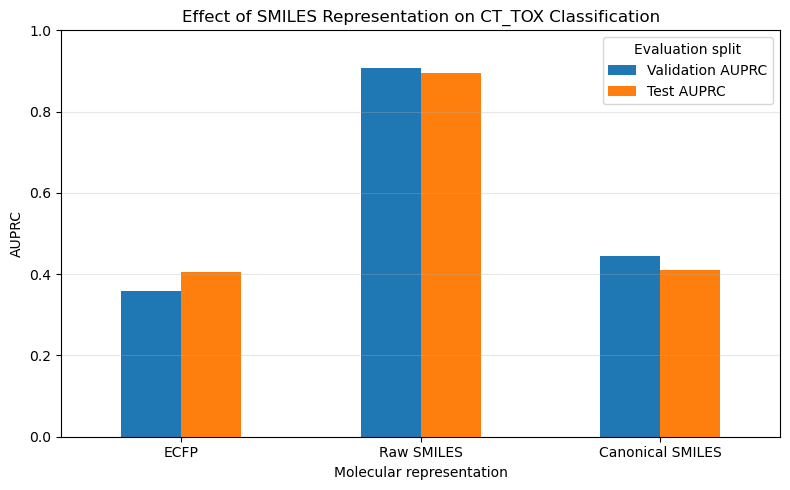

In [71]:
comparison_plot_df = representation_comparison.set_index(
    "Representation"
)

ax = comparison_plot_df.plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_xlabel("Molecular representation")
ax.set_ylabel("AUPRC")
ax.set_title(
    "Effect of SMILES Representation on CT_TOX Classification"
)

ax.set_ylim(0, 1.0)

plt.xticks(
    rotation=0,
)

plt.legend(
    title="Evaluation split",
)

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "representation_auprc_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


### Representation Audit: Interpretation

The character-level classifier trained on raw SMILES initially appeared to outperform the ECFP baseline by a large margin, reaching a test AUPRC of **0.896**, compared with **0.406** for the ECFP model. However, the representation audit shows that this apparent improvement must be interpreted cautiously.

Canonicalization confirmed that there was **no molecular overlap between the training, validation, and test splits**, ruling out direct cross-split duplication as an explanation for the high performance. Nevertheless, 19 canonical molecules were duplicated within the training set, and all 19 duplicated groups contained conflicting `CT_TOX` labels, revealing a source of label inconsistency in the dataset.

The raw SMILES strings also showed substantial class-associated differences in simple representation-level characteristics, including uppercase and lowercase character frequencies and the number of double-bond symbols. Because a character-level model operates directly on these textual patterns, it can potentially exploit serialization-specific correlations that are not equivalent to learning robust molecular structure–activity relationships.

To test this possibility, the same classifier architecture and training protocol were applied after converting every molecule to a canonical RDKit SMILES representation. Canonicalization reduced test AUPRC from **0.896 to 0.410**, while validation AUPRC decreased from **0.907 to 0.444**. The canonical-SMILES result was therefore much closer to the ECFP baseline (test AUPRC **0.406**) than to the raw-SMILES result.

This controlled experiment indicates that much of the apparent predictive advantage of the raw character-level model was **representation-dependent**. The result illustrates an important limitation of sequence-based molecular modeling: strong predictive performance can arise from dataset- or serialization-specific shortcuts rather than from generalizable chemical representations.

For this reason, the raw-SMILES classifier should not be interpreted as evidence that character-level SMILES embeddings are intrinsically superior to molecular fingerprints. Instead, it motivates the use of pretrained molecular language models and more rigorous representation controls in subsequent experiments.

## 6. Transfer Learning with ChemBERT

In this section, the pretrained ChemBERT model is adapted to the **CT_TOX** classification task from the ClinTox dataset.

Unlike the previous character-level models, ChemBERT starts from representations learned during large-scale molecular language-model pretraining. Fine-tuning therefore provides a more principled test of whether pretrained SMILES representations can transfer useful chemical information to a downstream toxicity-classification task.

Given the substantial class imbalance observed in `CT_TOX`, model evaluation continues to prioritize **AUPRC**, together with ROC-AUC, balanced accuracy, precision, recall, and F1-score. Model selection is performed exclusively on the validation set, while the test set remains reserved for final evaluation.

In [72]:
chembert_train_smiles = train_smiles_canonical
chembert_valid_smiles = valid_smiles_canonical
chembert_test_smiles = test_smiles_canonical

chembert_y_train = y_train_smiles.clone()
chembert_y_valid = y_valid_smiles.clone()
chembert_y_test = y_test_smiles.clone()

print("ChemBERT downstream dataset")
print("-" * 40)
print(f"Train samples      : {len(chembert_train_smiles)}")
print(f"Validation samples : {len(chembert_valid_smiles)}")
print(f"Test samples       : {len(chembert_test_smiles)}")
print(f"Target task        : {target_task}")

print("\nClass distribution")
print("-" * 40)
print(
    f"Train      : "
    f"{torch.bincount(chembert_y_train).tolist()}"
)
print(
    f"Validation : "
    f"{torch.bincount(chembert_y_valid).tolist()}"
)
print(
    f"Test       : "
    f"{torch.bincount(chembert_y_test).tolist()}"
)

ChemBERT downstream dataset
----------------------------------------
Train samples      : 1184
Validation samples : 148
Test samples       : 148
Target task        : CT_TOX

Class distribution
----------------------------------------
Train      : [1089, 95]
Validation : [141, 7]
Test       : [138, 10]


In [73]:
def get_tokenized_lengths(smiles_list):
    lengths = []

    for smiles in smiles_list:
        encoded = tokenizer(
            smiles,
            add_special_tokens=True,
            truncation=False,
        )

        lengths.append(
            len(encoded["input_ids"])
        )

    return np.array(lengths)


train_token_lengths = get_tokenized_lengths(
    chembert_train_smiles
)

valid_token_lengths = get_tokenized_lengths(
    chembert_valid_smiles
)

test_token_lengths = get_tokenized_lengths(
    chembert_test_smiles
)

print("ChemBERT token-length audit")
print("-" * 40)

print(
    f"Train max      : {train_token_lengths.max()}"
)
print(
    f"Validation max : {valid_token_lengths.max()}"
)
print(
    f"Test max       : {test_token_lengths.max()}"
)

print("\nTraining percentiles")
print("-" * 40)

for percentile in [90, 95, 99, 100]:
    value = np.percentile(
        train_token_lengths,
        percentile,
    )

    print(
        f"P{percentile:<3} : {value:.0f}"
    )

ChemBERT token-length audit
----------------------------------------
Train max      : 240
Validation max : 249
Test max       : 230

Training percentiles
----------------------------------------
P90  : 82
P95  : 108
P99  : 176
P100 : 240


In [74]:
CHEMBERT_MAX_LENGTH = 256

train_encoding = tokenizer(
    chembert_train_smiles,
    padding="max_length",
    truncation=True,
    max_length=CHEMBERT_MAX_LENGTH,
    return_tensors="pt",
)

valid_encoding = tokenizer(
    chembert_valid_smiles,
    padding="max_length",
    truncation=True,
    max_length=CHEMBERT_MAX_LENGTH,
    return_tensors="pt",
)

test_encoding = tokenizer(
    chembert_test_smiles,
    padding="max_length",
    truncation=True,
    max_length=CHEMBERT_MAX_LENGTH,
    return_tensors="pt",
)

print("ChemBERT tokenized tensors")
print("-" * 40)

print(
    f"Train input IDs      : "
    f"{tuple(train_encoding['input_ids'].shape)}"
)

print(
    f"Validation input IDs : "
    f"{tuple(valid_encoding['input_ids'].shape)}"
)

print(
    f"Test input IDs       : "
    f"{tuple(test_encoding['input_ids'].shape)}"
)

print("\nAttention masks")
print("-" * 40)

print(
    f"Train      : "
    f"{tuple(train_encoding['attention_mask'].shape)}"
)

print(
    f"Validation : "
    f"{tuple(valid_encoding['attention_mask'].shape)}"
)

print(
    f"Test       : "
    f"{tuple(test_encoding['attention_mask'].shape)}"
)

ChemBERT tokenized tensors
----------------------------------------
Train input IDs      : (1184, 256)
Validation input IDs : (148, 256)
Test input IDs       : (148, 256)

Attention masks
----------------------------------------
Train      : (1184, 256)
Validation : (148, 256)
Test       : (148, 256)


In [75]:
CHEMBERT_TRAIN_BATCH_SIZE = 8
CHEMBERT_EVAL_BATCH_SIZE = 16

train_chembert_dataset = TensorDataset(
    train_encoding["input_ids"],
    train_encoding["attention_mask"],
    chembert_y_train,
)

valid_chembert_dataset = TensorDataset(
    valid_encoding["input_ids"],
    valid_encoding["attention_mask"],
    chembert_y_valid,
)

test_chembert_dataset = TensorDataset(
    test_encoding["input_ids"],
    test_encoding["attention_mask"],
    chembert_y_test,
)


train_chembert_loader = DataLoader(
    train_chembert_dataset,
    batch_size=CHEMBERT_TRAIN_BATCH_SIZE,
    shuffle=True,
)

valid_chembert_loader = DataLoader(
    valid_chembert_dataset,
    batch_size=CHEMBERT_EVAL_BATCH_SIZE,
    shuffle=False,
)

test_chembert_loader = DataLoader(
    test_chembert_dataset,
    batch_size=CHEMBERT_EVAL_BATCH_SIZE,
    shuffle=False,
)


print("ChemBERT DataLoaders")
print("-" * 40)
print(f"Training batches   : {len(train_chembert_loader)}")
print(f"Validation batches : {len(valid_chembert_loader)}")
print(f"Test batches       : {len(test_chembert_loader)}")

ChemBERT DataLoaders
----------------------------------------
Training batches   : 148
Validation batches : 10
Test batches       : 10


In [80]:
chembert_classifier = AutoModelForSequenceClassification.from_pretrained(
    CHEMBERT_MODEL_NAME,
    num_labels=2,
).to(DEVICE)

# Freeze the pretrained ChemBERT encoder
for parameter in chembert_classifier.roberta.parameters():
    parameter.requires_grad = False

# Keep only the classification head trainable
for parameter in chembert_classifier.classifier.parameters():
    parameter.requires_grad = True


trainable_parameters = sum(
    parameter.numel()
    for parameter in chembert_classifier.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in chembert_classifier.parameters()
)

print("ChemBERT classifier")
print("-" * 40)
print(f"Model                : {CHEMBERT_MODEL_NAME}")
print(f"Num labels           : {chembert_classifier.config.num_labels}")
print(f"Device               : {DEVICE}")
print(f"Trainable parameters : {trainable_parameters:,}")
print(f"Total parameters     : {total_parameters:,}")
print(
    f"Trainable fraction   : "
    f"{100 * trainable_parameters / total_parameters:.2f}%"
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/PubChem10M_SMILES_BPE_450k and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ChemBERT classifier
----------------------------------------
Model                : seyonec/PubChem10M_SMILES_BPE_450k
Num labels           : 2
Device               : cpu
Trainable parameters : 592,130
Total parameters     : 83,450,882
Trainable fraction   : 0.71%


In [81]:
chembert_class_counts = torch.bincount(
    chembert_y_train
)

chembert_negative_count = chembert_class_counts[0].item()
chembert_positive_count = chembert_class_counts[1].item()

chembert_positive_weight = (
    chembert_negative_count
    / chembert_positive_count
)

chembert_class_weights = torch.tensor(
    [1.0, chembert_positive_weight],
    dtype=torch.float32,
    device=DEVICE,
)

chembert_criterion = nn.CrossEntropyLoss(
    weight=chembert_class_weights
)

chembert_optimizer = torch.optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        chembert_classifier.parameters(),
    ),
    lr=1e-3,
    weight_decay=0.01,
)

print("ChemBERT transfer-learning configuration")
print("-" * 40)
print(
    f"Positive-class weight : "
    f"{chembert_positive_weight:.3f}"
)
print("Encoder              : frozen")
print("Classification head  : trainable")
print("Learning rate        : 1e-3")
print("Weight decay         : 0.01")

ChemBERT transfer-learning configuration
----------------------------------------
Positive-class weight : 11.463
Encoder              : frozen
Classification head  : trainable
Learning rate        : 1e-3
Weight decay         : 0.01


In [82]:
def evaluate_chembert(
    model,
    loader,
    criterion,
):
    """Evaluate ChemBERT on a binary classification task."""

    model.eval()

    losses = []
    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for input_ids, attention_mask, labels in loader:
            input_ids = input_ids.to(DEVICE)
            attention_mask = attention_mask.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )

            logits = outputs.logits

            loss = criterion(
                logits,
                labels,
            )

            probabilities = torch.softmax(
                logits,
                dim=1,
            )[:, 1]

            predictions = torch.argmax(
                logits,
                dim=1,
            )

            losses.append(loss.item())

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    metrics = {
        "loss": np.mean(losses),
        "accuracy": accuracy_score(
            all_labels,
            all_predictions,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            all_labels,
            all_predictions,
        ),
        "precision": precision_score(
            all_labels,
            all_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            all_labels,
            all_predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            all_labels,
            all_predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            all_labels,
            all_probabilities,
        ),
        "auprc": average_precision_score(
            all_labels,
            all_probabilities,
        ),
    }

    return metrics

In [83]:
N_EPOCHS_CHEMBERT = 3

chembert_history = []

best_validation_auprc_chembert = -np.inf
best_epoch_chembert = None
best_model_state_chembert = None

for epoch in range(1, N_EPOCHS_CHEMBERT + 1):
    chembert_classifier.train()

    train_losses = []

    for input_ids, attention_mask, labels in train_chembert_loader:
        input_ids = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        labels = labels.to(DEVICE)

        chembert_optimizer.zero_grad()

        outputs = chembert_classifier(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        logits = outputs.logits

        loss = chembert_criterion(
            logits,
            labels,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            filter(
                lambda parameter: parameter.requires_grad,
                chembert_classifier.parameters(),
            ),
            max_norm=1.0,
        )

        chembert_optimizer.step()

        train_losses.append(
            loss.item()
        )

    train_metrics_chembert = evaluate_chembert(
        chembert_classifier,
        train_chembert_loader,
        chembert_criterion,
    )

    valid_metrics_chembert = evaluate_chembert(
        chembert_classifier,
        valid_chembert_loader,
        chembert_criterion,
    )

    chembert_history.append(
        {
            "epoch": epoch,
            "optimization_loss": np.mean(train_losses),
            "train_loss": train_metrics_chembert["loss"],
            "validation_loss": valid_metrics_chembert["loss"],
            "train_auprc": train_metrics_chembert["auprc"],
            "validation_auprc": valid_metrics_chembert["auprc"],
            "train_roc_auc": train_metrics_chembert["roc_auc"],
            "validation_roc_auc": valid_metrics_chembert["roc_auc"],
            "train_balanced_accuracy": train_metrics_chembert[
                "balanced_accuracy"
            ],
            "validation_balanced_accuracy": valid_metrics_chembert[
                "balanced_accuracy"
            ],
        }
    )

    if (
        valid_metrics_chembert["auprc"]
        > best_validation_auprc_chembert
    ):
        best_validation_auprc_chembert = (
            valid_metrics_chembert["auprc"]
        )

        best_epoch_chembert = epoch

        best_model_state_chembert = copy.deepcopy(
            chembert_classifier.state_dict()
        )

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss={train_metrics_chembert['loss']:.4f} | "
        f"Val loss={valid_metrics_chembert['loss']:.4f} | "
        f"Train AUPRC={train_metrics_chembert['auprc']:.3f} | "
        f"Val AUPRC={valid_metrics_chembert['auprc']:.3f} | "
        f"Val ROC-AUC={valid_metrics_chembert['roc_auc']:.3f}"
    )

chembert_history_df = pd.DataFrame(
    chembert_history
)

print(
    f"\nBest validation checkpoint: epoch "
    f"{best_epoch_chembert} "
    f"(AUPRC={best_validation_auprc_chembert:.3f})"
)

Epoch 01 | Train loss=0.5847 | Val loss=0.6628 | Train AUPRC=0.374 | Val AUPRC=0.085 | Val ROC-AUC=0.508
Epoch 02 | Train loss=0.5315 | Val loss=0.8155 | Train AUPRC=0.469 | Val AUPRC=0.139 | Val ROC-AUC=0.551
Epoch 03 | Train loss=0.9189 | Val loss=0.6952 | Train AUPRC=0.406 | Val AUPRC=0.124 | Val ROC-AUC=0.715

Best validation checkpoint: epoch 2 (AUPRC=0.139)


In [84]:
chembert_classifier.load_state_dict(
    best_model_state_chembert
)

train_metrics_chembert = evaluate_chembert(
    chembert_classifier,
    train_chembert_loader,
    chembert_criterion,
)

valid_metrics_chembert = evaluate_chembert(
    chembert_classifier,
    valid_chembert_loader,
    chembert_criterion,
)

test_metrics_chembert = evaluate_chembert(
    chembert_classifier,
    test_chembert_loader,
    chembert_criterion,
)

print(
    f"Best checkpoint restored from epoch "
    f"{best_epoch_chembert}\n"
)

for split_name, metrics in {
    "Train": train_metrics_chembert,
    "Validation": valid_metrics_chembert,
    "Test": test_metrics_chembert,
}.items():
    print(split_name)
    print("-" * 40)
    print(f"Loss              : {metrics['loss']:.4f}")
    print(f"Accuracy          : {metrics['accuracy']:.3f}")
    print(f"Balanced accuracy : {metrics['balanced_accuracy']:.3f}")
    print(f"Precision         : {metrics['precision']:.3f}")
    print(f"Recall            : {metrics['recall']:.3f}")
    print(f"F1-score          : {metrics['f1']:.3f}")
    print(f"ROC-AUC           : {metrics['roc_auc']:.3f}")
    print(f"AUPRC             : {metrics['auprc']:.3f}")
    print()

Best checkpoint restored from epoch 2

Train
----------------------------------------
Loss              : 0.5147
Accuracy          : 0.905
Balanced accuracy : 0.737
Precision         : 0.425
Recall            : 0.537
F1-score          : 0.474
ROC-AUC           : 0.856
AUPRC             : 0.469

Validation
----------------------------------------
Loss              : 0.8155
Accuracy          : 0.872
Balanced accuracy : 0.593
Precision         : 0.125
Recall            : 0.286
F1-score          : 0.174
ROC-AUC           : 0.551
AUPRC             : 0.139

Test
----------------------------------------
Loss              : 0.9249
Accuracy          : 0.770
Balanced accuracy : 0.552
Precision         : 0.100
Recall            : 0.300
F1-score          : 0.150
ROC-AUC           : 0.598
AUPRC             : 0.146



In [85]:
chembert_results = pd.DataFrame(
    [
        {
            "Model": "ChemBERT Frozen Encoder",
            "Task": target_task,
            "Best epoch": best_epoch_chembert,
            "Positive class weight": chembert_positive_weight,
            "Trainable fraction (%)": (
                100 * trainable_parameters / total_parameters
            ),
            "Train accuracy": train_metrics_chembert["accuracy"],
            "Train balanced accuracy": train_metrics_chembert[
                "balanced_accuracy"
            ],
            "Train ROC-AUC": train_metrics_chembert["roc_auc"],
            "Train AUPRC": train_metrics_chembert["auprc"],
            "Validation accuracy": valid_metrics_chembert["accuracy"],
            "Validation balanced accuracy": valid_metrics_chembert[
                "balanced_accuracy"
            ],
            "Validation ROC-AUC": valid_metrics_chembert["roc_auc"],
            "Validation AUPRC": valid_metrics_chembert["auprc"],
            "Test accuracy": test_metrics_chembert["accuracy"],
            "Test balanced accuracy": test_metrics_chembert[
                "balanced_accuracy"
            ],
            "Test precision": test_metrics_chembert["precision"],
            "Test recall": test_metrics_chembert["recall"],
            "Test F1": test_metrics_chembert["f1"],
            "Test ROC-AUC": test_metrics_chembert["roc_auc"],
            "Test AUPRC": test_metrics_chembert["auprc"],
        }
    ]
)

chembert_history_df.to_csv(
    TABLES_DIR / "chembert_frozen_training_history.csv",
    index=False,
)

chembert_results.to_csv(
    TABLES_DIR / "chembert_frozen_results.csv",
    index=False,
)

chembert_results

,Model,Task,Best epoch,Positive class weight,Trainable fraction (%),Train accuracy,Train balanced accuracy,Train ROC-AUC,Train AUPRC,Validation accuracy,Validation balanced accuracy,Validation ROC-AUC,Validation AUPRC,Test accuracy,Test balanced accuracy,Test precision,Test recall,Test F1,Test ROC-AUC,Test AUPRC
0,ChemBERT Frozen Encoder,CT_TOX,2,11.463158,0.709555,0.904561,0.736741,0.856329,0.468865,0.871622,0.593212,0.551165,0.138627,0.77027,0.552174,0.1,0.3,0.15,0.597826,0.145742


### Partial Fine-Tuning Strategy

Training only the classification head provides a computationally efficient transfer-learning baseline, but it assumes that the pretrained ChemBERT representation is already directly suitable for the `CT_TOX` task.

The frozen-encoder model achieved limited generalization, with a validation AUPRC of **0.139** and a test AUPRC of **0.146**. This suggests that a fixed pretrained representation may not be sufficient for the downstream toxicity task.

As an intermediate strategy between feature extraction and full-model fine-tuning, the following experiment unfreezes only the **final Transformer layer** together with the classification head. This allows the highest-level molecular representation to adapt to the downstream task while keeping most of the pretrained encoder frozen and limiting computational cost.

In [87]:
partial_chembert_classifier = (
    AutoModelForSequenceClassification.from_pretrained(
        CHEMBERT_MODEL_NAME,
        num_labels=2,
    ).to(DEVICE)
)

# Freeze the complete model first
for parameter in partial_chembert_classifier.parameters():
    parameter.requires_grad = False

# Unfreeze the final Transformer layer
for parameter in (
    partial_chembert_classifier
    .roberta
    .encoder
    .layer[-1]
    .parameters()
):
    parameter.requires_grad = True

# Unfreeze the classification head
for parameter in (
    partial_chembert_classifier
    .classifier
    .parameters()
):
    parameter.requires_grad = True


partial_trainable_parameters = sum(
    parameter.numel()
    for parameter in partial_chembert_classifier.parameters()
    if parameter.requires_grad
)

partial_total_parameters = sum(
    parameter.numel()
    for parameter in partial_chembert_classifier.parameters()
)

print("ChemBERT partial fine-tuning")
print("-" * 40)
print("Unfrozen Transformer layers : 1")
print("Classification head         : trainable")
print(
    f"Trainable parameters        : "
    f"{partial_trainable_parameters:,}"
)
print(
    f"Total parameters            : "
    f"{partial_total_parameters:,}"
)
print(
    f"Trainable fraction          : "
    f"{100 * partial_trainable_parameters / partial_total_parameters:.2f}%"
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/PubChem10M_SMILES_BPE_450k and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ChemBERT partial fine-tuning
----------------------------------------
Unfrozen Transformer layers : 1
Classification head         : trainable
Trainable parameters        : 7,680,002
Total parameters            : 83,450,882
Trainable fraction          : 9.20%


In [88]:
partial_chembert_criterion = nn.CrossEntropyLoss(
    weight=chembert_class_weights
)

partial_chembert_optimizer = torch.optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        partial_chembert_classifier.parameters(),
    ),
    lr=2e-5,
    weight_decay=0.01,
)

print("Partial fine-tuning configuration")
print("-" * 40)
print(
    f"Positive-class weight : "
    f"{chembert_positive_weight:.3f}"
)
print("Unfrozen encoder layers: 1")
print("Classification head   : trainable")
print("Learning rate         : 2e-5")
print("Weight decay          : 0.01")

Partial fine-tuning configuration
----------------------------------------
Positive-class weight : 11.463
Unfrozen encoder layers: 1
Classification head   : trainable
Learning rate         : 2e-5
Weight decay          : 0.01


In [89]:
N_EPOCHS_PARTIAL_CHEMBERT = 3

partial_chembert_history = []

best_validation_auprc_partial = -np.inf
best_epoch_partial = None
best_model_state_partial = None

for epoch in range(1, N_EPOCHS_PARTIAL_CHEMBERT + 1):
    partial_chembert_classifier.train()

    train_losses = []

    for input_ids, attention_mask, labels in train_chembert_loader:
        input_ids = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        labels = labels.to(DEVICE)

        partial_chembert_optimizer.zero_grad()

        outputs = partial_chembert_classifier(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        logits = outputs.logits

        loss = partial_chembert_criterion(
            logits,
            labels,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            filter(
                lambda parameter: parameter.requires_grad,
                partial_chembert_classifier.parameters(),
            ),
            max_norm=1.0,
        )

        partial_chembert_optimizer.step()

        train_losses.append(
            loss.item()
        )

    train_metrics_partial = evaluate_chembert(
        partial_chembert_classifier,
        train_chembert_loader,
        partial_chembert_criterion,
    )

    valid_metrics_partial = evaluate_chembert(
        partial_chembert_classifier,
        valid_chembert_loader,
        partial_chembert_criterion,
    )

    partial_chembert_history.append(
        {
            "epoch": epoch,
            "optimization_loss": np.mean(train_losses),
            "train_loss": train_metrics_partial["loss"],
            "validation_loss": valid_metrics_partial["loss"],
            "train_auprc": train_metrics_partial["auprc"],
            "validation_auprc": valid_metrics_partial["auprc"],
            "train_roc_auc": train_metrics_partial["roc_auc"],
            "validation_roc_auc": valid_metrics_partial["roc_auc"],
            "train_balanced_accuracy": train_metrics_partial[
                "balanced_accuracy"
            ],
            "validation_balanced_accuracy": valid_metrics_partial[
                "balanced_accuracy"
            ],
        }
    )

    if (
        valid_metrics_partial["auprc"]
        > best_validation_auprc_partial
    ):
        best_validation_auprc_partial = (
            valid_metrics_partial["auprc"]
        )

        best_epoch_partial = epoch

        best_model_state_partial = copy.deepcopy(
            partial_chembert_classifier.state_dict()
        )

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss={train_metrics_partial['loss']:.4f} | "
        f"Val loss={valid_metrics_partial['loss']:.4f} | "
        f"Train AUPRC={train_metrics_partial['auprc']:.3f} | "
        f"Val AUPRC={valid_metrics_partial['auprc']:.3f} | "
        f"Val ROC-AUC={valid_metrics_partial['roc_auc']:.3f}"
    )

partial_chembert_history_df = pd.DataFrame(
    partial_chembert_history
)

print(
    f"\nBest validation checkpoint: epoch "
    f"{best_epoch_partial} "
    f"(AUPRC={best_validation_auprc_partial:.3f})"
)

Epoch 01 | Train loss=1.0059 | Val loss=0.8930 | Train AUPRC=0.340 | Val AUPRC=0.113 | Val ROC-AUC=0.712
Epoch 02 | Train loss=0.7456 | Val loss=0.7391 | Train AUPRC=0.473 | Val AUPRC=0.115 | Val ROC-AUC=0.682
Epoch 03 | Train loss=0.5813 | Val loss=0.8244 | Train AUPRC=0.650 | Val AUPRC=0.095 | Val ROC-AUC=0.595

Best validation checkpoint: epoch 2 (AUPRC=0.115)


In [91]:
partial_chembert_classifier.load_state_dict(
    best_model_state_partial
)

train_metrics_partial = evaluate_chembert(
    partial_chembert_classifier,
    train_chembert_loader,
    partial_chembert_criterion,
)

valid_metrics_partial = evaluate_chembert(
    partial_chembert_classifier,
    valid_chembert_loader,
    partial_chembert_criterion,
)

test_metrics_partial = evaluate_chembert(
    partial_chembert_classifier,
    test_chembert_loader,
    partial_chembert_criterion,
)

print(
    f"Best checkpoint restored from epoch "
    f"{best_epoch_partial}\n"
)

for split_name, metrics in {
    "Train": train_metrics_partial,
    "Validation": valid_metrics_partial,
    "Test": test_metrics_partial,
}.items():
    print(split_name)
    print("-" * 40)
    print(f"Loss              : {metrics['loss']:.4f}")
    print(f"Accuracy          : {metrics['accuracy']:.3f}")
    print(f"Balanced accuracy : {metrics['balanced_accuracy']:.3f}")
    print(f"Precision         : {metrics['precision']:.3f}")
    print(f"Recall            : {metrics['recall']:.3f}")
    print(f"F1-score          : {metrics['f1']:.3f}")
    print(f"ROC-AUC           : {metrics['roc_auc']:.3f}")
    print(f"AUPRC             : {metrics['auprc']:.3f}")
    print()

Best checkpoint restored from epoch 2

Train
----------------------------------------
Loss              : 0.7702
Accuracy          : 0.924
Balanced accuracy : 0.546
Precision         : 0.692
Recall            : 0.095
F1-score          : 0.167
ROC-AUC           : 0.871
AUPRC             : 0.473

Validation
----------------------------------------
Loss              : 0.7391
Accuracy          : 0.953
Balanced accuracy : 0.500
Precision         : 0.000
Recall            : 0.000
F1-score          : 0.000
ROC-AUC           : 0.682
AUPRC             : 0.115

Test
----------------------------------------
Loss              : 1.0198
Accuracy          : 0.939
Balanced accuracy : 0.550
Precision         : 1.000
Recall            : 0.100
F1-score          : 0.182
ROC-AUC           : 0.521
AUPRC             : 0.258



In [92]:
partial_chembert_results = pd.DataFrame(
    [
        {
            "Model": "ChemBERT Partial Fine-Tuning",
            "Task": target_task,
            "Best epoch": best_epoch_partial,
            "Positive class weight": chembert_positive_weight,
            "Trainable fraction (%)": (
                100
                * partial_trainable_parameters
                / partial_total_parameters
            ),
            "Train accuracy": train_metrics_partial["accuracy"],
            "Train balanced accuracy": train_metrics_partial[
                "balanced_accuracy"
            ],
            "Train ROC-AUC": train_metrics_partial["roc_auc"],
            "Train AUPRC": train_metrics_partial["auprc"],
            "Validation accuracy": valid_metrics_partial["accuracy"],
            "Validation balanced accuracy": valid_metrics_partial[
                "balanced_accuracy"
            ],
            "Validation ROC-AUC": valid_metrics_partial["roc_auc"],
            "Validation AUPRC": valid_metrics_partial["auprc"],
            "Test accuracy": test_metrics_partial["accuracy"],
            "Test balanced accuracy": test_metrics_partial[
                "balanced_accuracy"
            ],
            "Test precision": test_metrics_partial["precision"],
            "Test recall": test_metrics_partial["recall"],
            "Test F1": test_metrics_partial["f1"],
            "Test ROC-AUC": test_metrics_partial["roc_auc"],
            "Test AUPRC": test_metrics_partial["auprc"],
        }
    ]
)

partial_chembert_history_df.to_csv(
    TABLES_DIR / "chembert_partial_training_history.csv",
    index=False,
)

partial_chembert_results.to_csv(
    TABLES_DIR / "chembert_partial_results.csv",
    index=False,
)

partial_chembert_results

,Model,Task,Best epoch,Positive class weight,Trainable fraction (%),Train accuracy,Train balanced accuracy,Train ROC-AUC,Train AUPRC,Validation accuracy,Validation balanced accuracy,Validation ROC-AUC,Validation AUPRC,Test accuracy,Test balanced accuracy,Test precision,Test recall,Test F1,Test ROC-AUC,Test AUPRC
0,ChemBERT Partial Fine-Tuning,CT_TOX,2,11.463158,9.203021,0.923986,0.545532,0.870577,0.472651,0.952703,0.5,0.681864,0.114909,0.939189,0.55,1.0,0.1,0.181818,0.521014,0.258367


In [93]:
final_model_comparison = pd.DataFrame(
    [
        {
            "Model": "ECFP FeedForward",
            "Validation AUPRC": valid_metrics["auprc"],
            "Test AUPRC": test_metrics["auprc"],
            "Test ROC-AUC": test_metrics["roc_auc"],
            "Test balanced accuracy": test_metrics[
                "balanced_accuracy"
            ],
            "Test F1": test_metrics["f1"],
        },
        {
            "Model": "Raw SMILES",
            "Validation AUPRC": valid_metrics_smiles["auprc"],
            "Test AUPRC": test_metrics_smiles["auprc"],
            "Test ROC-AUC": test_metrics_smiles["roc_auc"],
            "Test balanced accuracy": test_metrics_smiles[
                "balanced_accuracy"
            ],
            "Test F1": test_metrics_smiles["f1"],
        },
        {
            "Model": "Canonical SMILES",
            "Validation AUPRC": valid_metrics_canonical["auprc"],
            "Test AUPRC": test_metrics_canonical["auprc"],
            "Test ROC-AUC": test_metrics_canonical["roc_auc"],
            "Test balanced accuracy": test_metrics_canonical[
                "balanced_accuracy"
            ],
            "Test F1": test_metrics_canonical["f1"],
        },
        {
            "Model": "ChemBERT Frozen",
            "Validation AUPRC": valid_metrics_chembert["auprc"],
            "Test AUPRC": test_metrics_chembert["auprc"],
            "Test ROC-AUC": test_metrics_chembert["roc_auc"],
            "Test balanced accuracy": test_metrics_chembert[
                "balanced_accuracy"
            ],
            "Test F1": test_metrics_chembert["f1"],
        },
        {
            "Model": "ChemBERT Partial",
            "Validation AUPRC": valid_metrics_partial["auprc"],
            "Test AUPRC": test_metrics_partial["auprc"],
            "Test ROC-AUC": test_metrics_partial["roc_auc"],
            "Test balanced accuracy": test_metrics_partial[
                "balanced_accuracy"
            ],
            "Test F1": test_metrics_partial["f1"],
        },
    ]
)

final_model_comparison = final_model_comparison.round(3)

final_model_comparison.to_csv(
    TABLES_DIR / "final_model_comparison.csv",
    index=False,
)

final_model_comparison

,Model,Validation AUPRC,Test AUPRC,Test ROC-AUC,Test balanced accuracy,Test F1
0,ECFP FeedForward,0.358,0.406,0.679,0.617,0.216
1,Raw SMILES,0.907,0.896,0.988,0.936,0.783
2,Canonical SMILES,0.444,0.410,0.904,0.795,0.340
3,ChemBERT Frozen,0.139,0.146,0.598,0.552,0.150
4,ChemBERT Partial,0.115,0.258,0.521,0.550,0.182


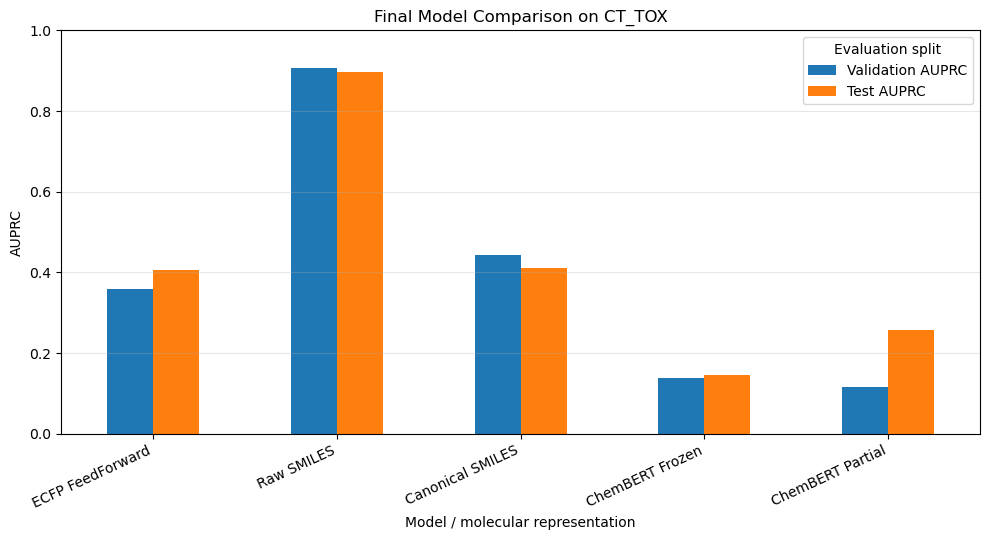

In [94]:
final_auprc_plot = (
    final_model_comparison[
        [
            "Model",
            "Validation AUPRC",
            "Test AUPRC",
        ]
    ]
    .set_index("Model")
)

ax = final_auprc_plot.plot(
    kind="bar",
    figsize=(10, 5.5),
)

ax.set_xlabel("Model / molecular representation")
ax.set_ylabel("AUPRC")
ax.set_title(
    "Final Model Comparison on CT_TOX"
)

ax.set_ylim(0, 1.0)

plt.xticks(
    rotation=25,
    ha="right",
)

plt.legend(
    title="Evaluation split",
)

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "final_model_auprc_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Transfer Learning Results

ChemBERT was evaluated under two computationally constrained transfer-learning strategies. First, the pretrained encoder was kept frozen and only the classification head was trained, corresponding to approximately **0.71% of the model parameters**. This configuration achieved a validation AUPRC of **0.139** and a test AUPRC of **0.146**, indicating limited transfer of the fixed pretrained representation to the `CT_TOX` classification task.

A second experiment allowed limited task-specific adaptation by unfreezing the final Transformer layer together with the classification head, increasing the trainable fraction to approximately **9.20%**. The best validation checkpoint reached an AUPRC of **0.115**. At this checkpoint, validation recall was zero and balanced accuracy was 0.500, indicating that the thresholded classifier failed to identify positive validation examples. Test AUPRC was **0.258**, but this higher test value should not be interpreted as evidence that partial fine-tuning outperformed the frozen configuration because model selection was performed exclusively on the validation split.

Overall, neither transfer-learning strategy improved upon the ECFP or canonical-SMILES baselines. These results show that molecular pretraining alone does not guarantee improved downstream performance, particularly for a small and strongly imbalanced dataset. More extensive fine-tuning, alternative pretrained molecular models, hyperparameter optimization, or larger task-specific datasets could potentially improve transfer, but were outside the computational scope of the present experiment.

## 7. Discussion and Conclusions

The experiments demonstrate that molecular representation has a major impact on apparent predictive performance for the highly imbalanced `CT_TOX` task.

The ECFP feedforward classifier provided a conventional structure-based baseline, achieving a test AUPRC of **0.406**. A character-level model trained directly on raw SMILES produced substantially higher apparent performance, reaching a test AUPRC of **0.896**, ROC-AUC of **0.988**, and balanced accuracy of **0.936**.

However, additional data auditing revealed an important limitation of this result. Canonicalization identified **19 molecular structures represented more than once in the training set with conflicting labels**, while no canonical molecular overlap was detected between train, validation, and test splits. More importantly, the raw SMILES representation contained pronounced class-associated differences in sequence statistics and notation patterns. When the same molecular structures were converted to canonical SMILES and the character-level classifier was retrained, test AUPRC decreased from **0.896 to 0.410**.

This large performance reduction indicates that the raw-SMILES classifier was strongly dependent on representation-specific regularities rather than exclusively on chemically meaningful structural information. The canonical-SMILES result was instead comparable to the ECFP baseline in AUPRC, while achieving higher test ROC-AUC (**0.904 vs. 0.679**), balanced accuracy (**0.795 vs. 0.617**), and F1-score (**0.340 vs. 0.216**).

Transfer learning with pretrained ChemBERT representations did not improve downstream performance under the computationally accessible strategies evaluated here. The frozen-encoder configuration achieved a test AUPRC of **0.146**, while partial fine-tuning of the final Transformer layer produced a test AUPRC of **0.258**. Neither configuration exceeded the ECFP or canonical-SMILES baselines.

Taken together, these experiments illustrate why molecular machine-learning models should not be evaluated solely by their highest predictive score. Representation artifacts, duplicate structures, conflicting annotations, class imbalance, and model-selection procedures can substantially affect apparent performance. In this dataset, the strongest numerical result was obtained with raw SMILES, but the representation audit demonstrated that this result was not robust to molecular canonicalization.

The main outcome of the analysis is therefore methodological rather than the identification of a single superior classifier: **careful molecular data auditing and representation controls are essential for distinguishing genuine predictive signal from representation-dependent shortcuts**.